In [2]:
data = [
    # -------------------------------
    # Cosmological Model Dependent
    # -------------------------------
    {"group": "model", "label": "CMB (Planck)",  "H0": 67.4, "err": 0.5, "color": "forestgreen"},
    {"group": "model", "label": "CMB (WMAP + ACT)","H0": 67.6, "err": 1.1, "color": "green"},
    {"group": "model", "label": "CMB (WMAP + SPT)","H0": 68.2, "err": 1.1, "color": "green"},
    {"group": "model", "label": "DESI-DR1 BAO + BBN + " + r'${\theta}_{\star}$',"H0": 68.52, "err": 0.62, "color": "green"},
    {"group": "model", "label": "DESI-DR1 BAO + CMB","H0": 67.97, "err": 0.38, "color": "green"},
    {"group": "model", "label": "DESI-DR2 BAO + BBN + " + r'${\theta}_{\star}$',"H0": 68.45, "err": 0.47, "color": "green"},
    {"group": "model", "label": "DESI-DR2 BAO + CMB","H0": 68.17, "err": 0.28, "color": "green"},


    # -------------------------------
    # Direct (D vs z)
    # -------------------------------
    {"group": "direct", "label": r"SN Ia - Cepheids (S$H_0$ES/HST)","H0": 73.04, "err": 1.04, "color": "red"},
    {"group": "direct", "label": r"SN Ia - Cepheids (CCHP/JWST)","H0": 72.05, "err": 1.86, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - Cepheids (S$H_0$ES/HST)","H0": 73.40, "err": 2.10, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - Cepheids (S$H_0$ES/JWST)","H0": 73.20, "err": 0.90, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - TRGB (CCHP/HST)","H0": 69.80, "err": 0.80, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - TRGB (Anand et al./HST)","H0": 71.50, "err": 1.80, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - TRGB (CCHP/JWST)","H0": 69.85, "err": 1.75, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - JAGB (CCHP/JWST)","H0": 67.96, "err": 1.85, "color": "salmon"},

]

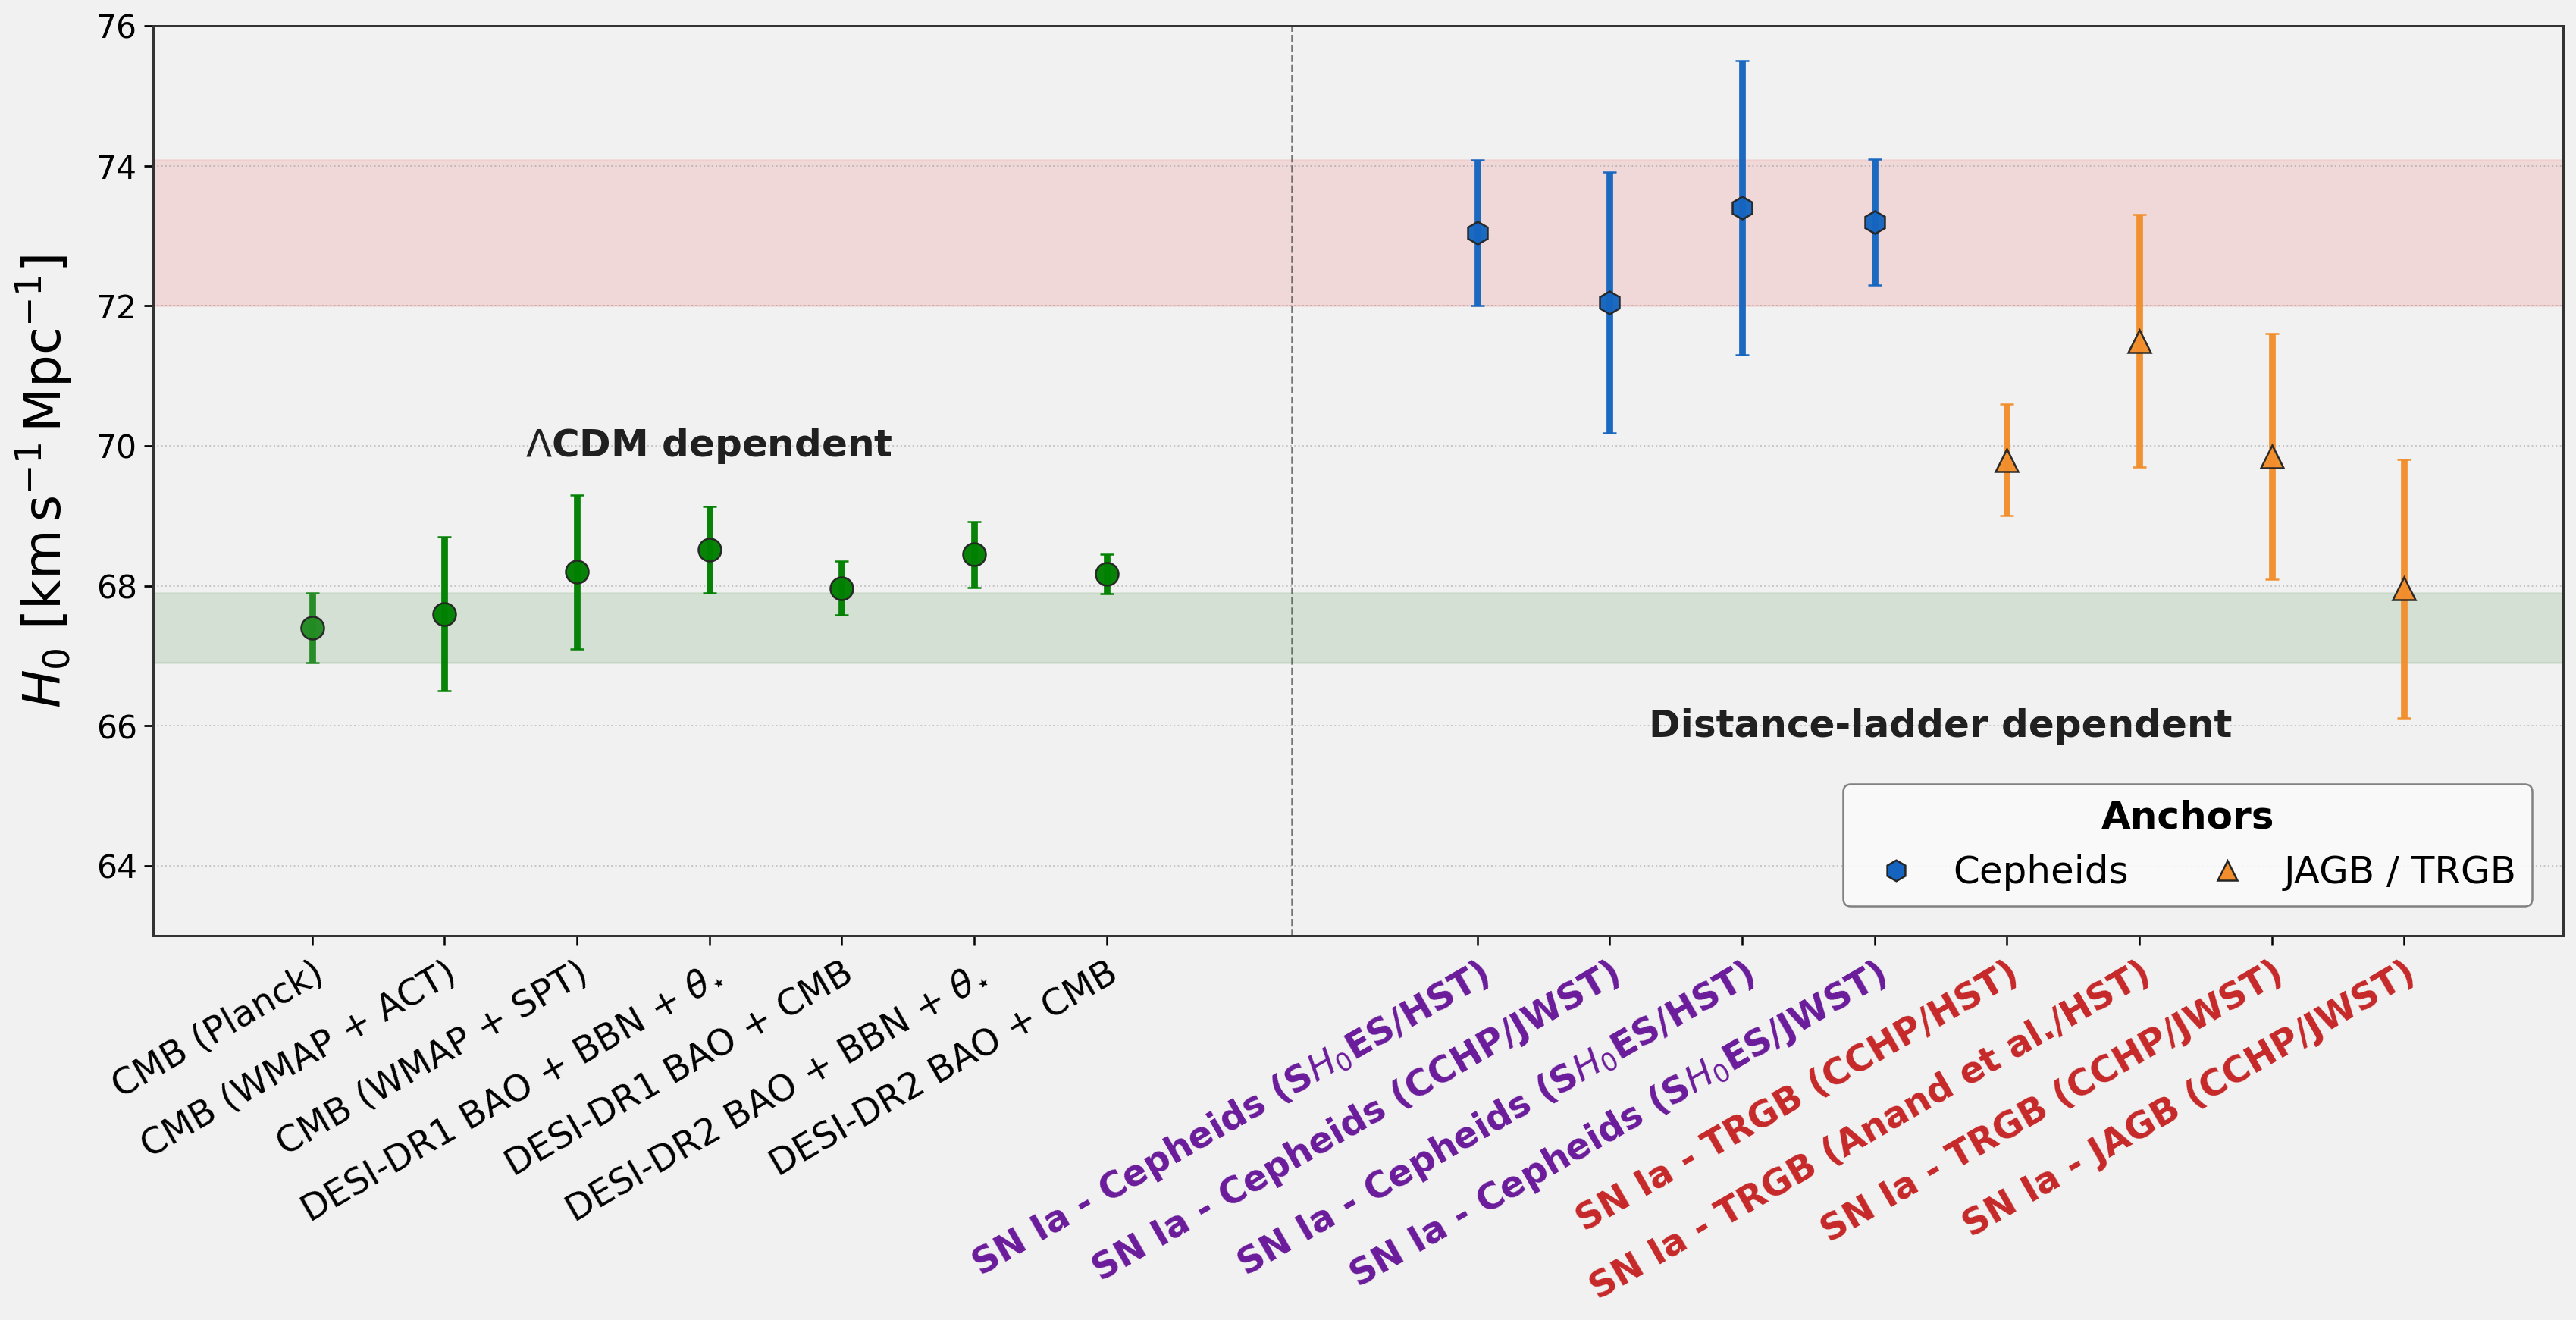

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ============================================================
# Clasificación visual
# ============================================================

def visual_style(label, original_color):
    """
    Retorna:
        marker, point_color, label_color, label_weight
    """
    label_upper = label.upper()

    if "TRGB" in label_upper or "JAGB" in label_upper:
        return "^", "#F28E2B", "#C62828", "bold"

    if "CEPHEID" in label_upper or "CEPH." in label_upper:
        return "h", "#1565C0", "#6A1B9A", "bold"

    return "o", original_color, "black", "normal"


# ============================================================
# Posiciones en x con espacios entre grupos
# ============================================================

gap = 1.8

x_positions = []
labels = []

group_positions = {
    "model": [],
    "direct": [],
}

separator_positions = []

current_x = 0
prev_group = data[0]["group"]

for i, d in enumerate(data):

    if i > 0 and d["group"] != prev_group:
        separator_positions.append(current_x - 0.5 + gap / 2)
        current_x += gap
        prev_group = d["group"]

    x_positions.append(current_x)
    labels.append(d["label"])
    group_positions[d["group"]].append(current_x)

    current_x += 1


# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(figsize=(19.3, 10.584), dpi=180)

bg = "#F1F1F1"

fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)


# ============================================================
# Bandas de referencia
# ============================================================

# Planck
ax.axhspan(
    66.9, 67.9,
    color="#66A061",
    alpha=0.20,
    zorder=0
)

# SH0ES
ax.axhspan(
    72.0, 74.08,
    color="#EF6A6A",
    alpha=0.18,
    zorder=0
)


# ============================================================
# Rejilla horizontal
# ============================================================

ax.grid(
    axis="y",
    linestyle=":",
    linewidth=0.8,
    color="#777777",
    alpha=0.35,
    zorder=0
)


# ============================================================
# Separadores verticales
# ============================================================

for sep in separator_positions:
    ax.axvline(
        sep,
        color="#333333",
        linestyle="--",
        linewidth=1.0,
        alpha=0.65,
        zorder=1
    )


# ============================================================
# Puntos y barras de error
# ============================================================

for x, d in zip(x_positions, data):

    marker, point_color, _, _ = visual_style(
        d["label"],
        d["color"]
    )

    ax.errorbar(
        x,
        d["H0"],
        yerr=d["err"],
        fmt=marker,
        markersize=12,
        markerfacecolor=point_color,
        markeredgecolor="#252525",
        markeredgewidth=1.0,
        color=point_color,
        ecolor=point_color,
        elinewidth=3.5,
        capsize=3.5,
        capthick=3.5,
        alpha=0.97,
        zorder=3
    )


# ============================================================
# Ejes
# ============================================================

ax.set_xlim(
    min(x_positions) - 1.2,
    max(x_positions) + 1.2
)

ax.set_ylim(63, 70)

ax.set_xticks(x_positions)

ax.set_xticklabels(
    labels,
    rotation=30,
    ha="right",
    rotation_mode="anchor",
    fontsize=19
)

# Dar formato individual a cada etiqueta
for tick_label, d in zip(ax.get_xticklabels(), data):

    _, _, text_color, text_weight = visual_style(
        d["label"],
        d["color"]
    )

    tick_label.set_color(text_color)
    tick_label.set_fontweight(text_weight)

ax.set_yticks(np.arange(64, 77, 2))

ax.tick_params(
    axis="y",
    labelsize=17,
    width=1.1,
    length=5
)

ax.tick_params(
    axis="x",
    width=1.0,
    length=5,
    pad=5
)

ax.set_ylabel(
    r"$H_0\ [\mathrm{km\,s^{-1}\,Mpc^{-1}}]$",
    fontsize=27,
    fontweight="bold",
    labelpad=12
)


# ============================================================
# Títulos de los grupos
# ============================================================

#group_title_y = 76
#group_title_size = 20

group_titles = {
    "model": r"$\Lambda$CDM dependent",
    "direct": "Distance-ladder dependent",
}


ax.text(
    np.mean(group_positions["model"]),
    70,
    group_titles["model"],
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold",
    color="#202020"
)

ax.text(
    np.mean(group_positions["direct"]),
    66,
    group_titles["direct"],
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold",
    color="#202020"
)



# ============================================================
# Leyenda de símbolos
# ============================================================

legend_elements = [
    #Line2D(
    #    [0], [0],
    #    marker="o",
    #    linestyle="none",
    #    markersize=9,
    #    markerfacecolor="#555555",
    #    markeredgecolor="#252525",
    #    label="No-ladder"
    #),
    Line2D(
        [0], [0],
        marker="h",
        linestyle="none",
        markersize=11,
        markerfacecolor="#1565C0",
        markeredgecolor="#252525",
        label="Cepheids"
    ),
    Line2D(
    [0], [0],
    marker="^",
    linestyle="none",
    markersize=10.5,
    markerfacecolor="#F28E2B",
    markeredgecolor="#252525",
    label="JAGB / TRGB"
    ),
]


legend = ax.legend(
    title="Anchors", 
    handles=legend_elements, 
    loc="lower right", 
    bbox_to_anchor=(0.995, 0.012), 
    ncol=3, 
    fontsize=20, 
    frameon=True, 
    framealpha=0.92, 
    edgecolor="#777777", 
    columnspacing=1.6, 
    handletextpad=0.5,
    title_fontproperties={'size': 20, 'weight': 'bold'} 
)

legend.get_frame().set_facecolor("#FAFAFA")


# ============================================================
# Bordes
# ============================================================

for spine in ax.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color("#333333")


# Espacio para etiquetas inclinadas y ecuaciones superiores
plt.subplots_adjust(
    left=0.07,
    right=0.985,
    top=0.94,
    bottom=0.31
)

plt.savefig(
    "CFH_HubbleTension.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
    #facecolor=fig.get_facecolor()
)

plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

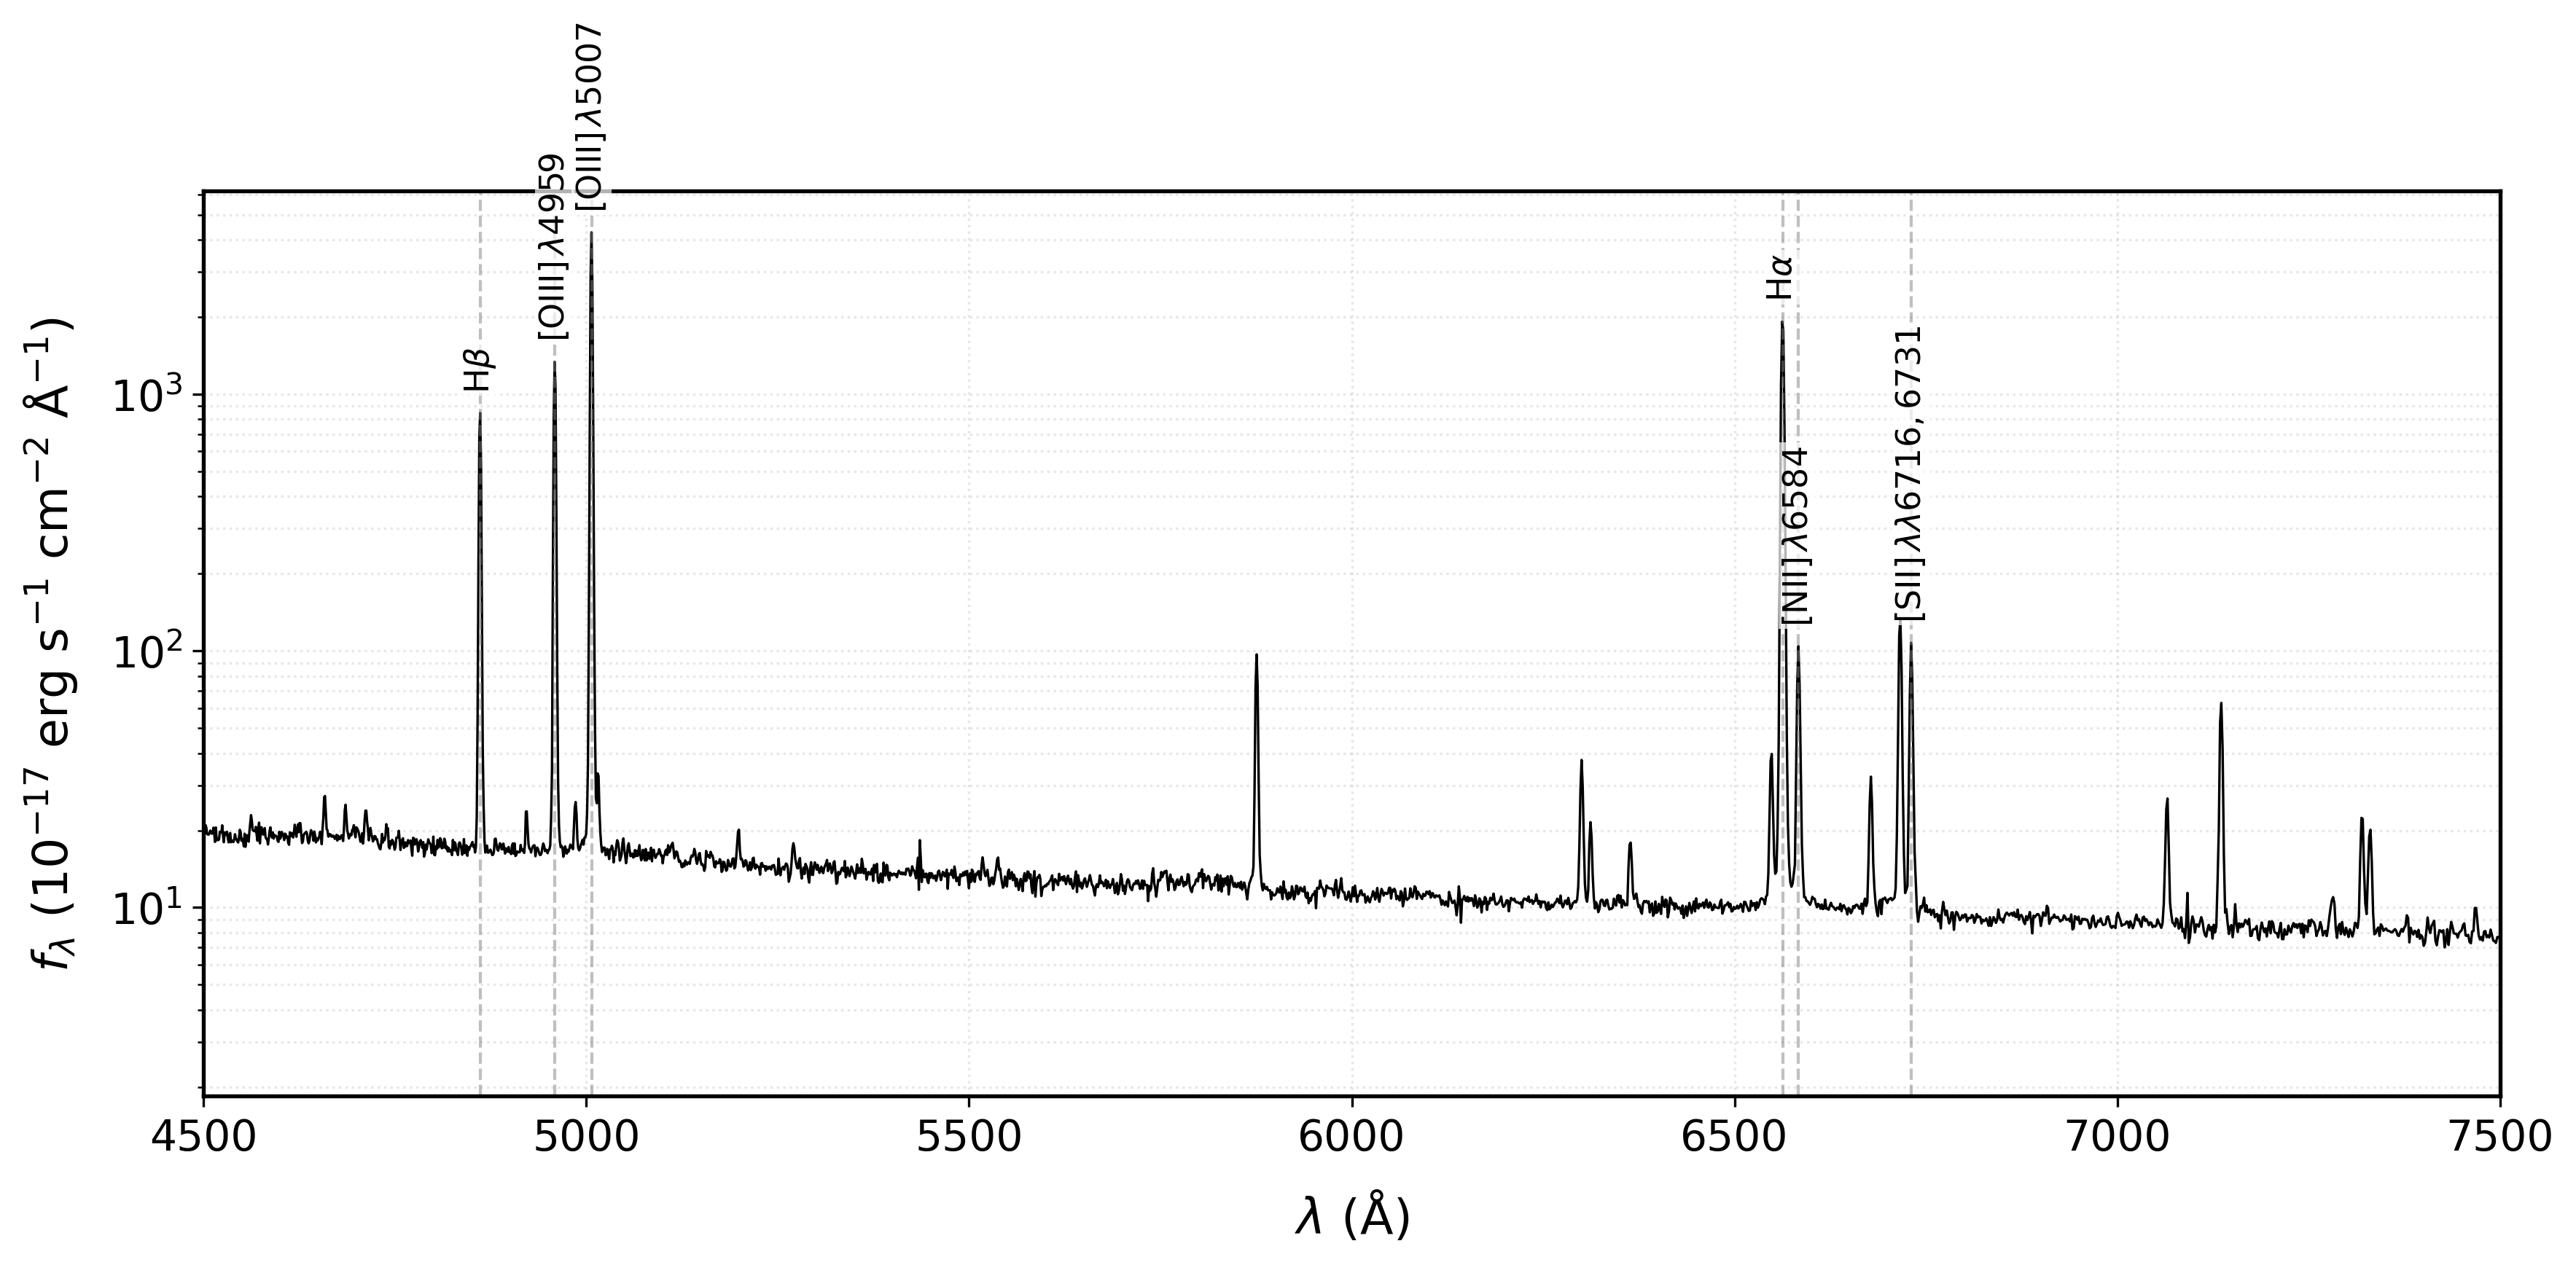

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# 1. Configuración de estilo tipo LaTeX para póster científico
plt.rcParams.update({
    "text.usetex": False,            # Habilita el renderizado de LaTeX
    "font.family": "serif",         # Tipografía con serifas clásica de LaTeX
    "font.serif": ["Computer Modern"], 
    "axes.labelsize": 16,           # Tamaño de etiquetas de los ejes
    "font.size": 14,                # Tamaño de fuente general
    "legend.fontsize": 12,          # Tamaño de la leyenda
    "xtick.labelsize": 14,          # Tamaño de números en el eje X
    "ytick.labelsize": 14,          # Tamaño de números en el eje Y
    "figure.titlesize": 18          # Tamaño del título principal
})

# 2. Cargar el archivo FITS de SDSS DR7
# Reemplaza 'espectro_dr7.fits' con la ruta de tu archivo descargado
fits_filename = 'spSpec-51910-0275-445.fit'

with fits.open(fits_filename) as hdul:
    data = hdul[0].data
    header = hdul[0].header
    zz = hdul[0].header['Z']
    # En SDSS DR7, los datos suelen extraerse de la tabla de la extensión 1
    # La longitud de onda está guardada en escala logarítmica base 10 (loglam)
    flux = data[0]
    wav00 = hdul[0].header['COEFF0']
    wavdiff = hdul[0].header['COEFF1']

    waveair = 10**(wav00 + wavdiff*np.arange(len(flux)))

    wavelength = waveair/(1.0+2.735182E-4+131.4182/(waveair)**2 +2.76249E8/(waveair)**4)
    wavelength = wavelength/(1.0+zz)
# 3. Definición de las líneas de emisión clave (Galaxia HII)
# Longitudes de onda en el aire (vacío/aire estándar)
lineas_emision = {
    r'$\mathrm{H}\beta$': 4861.3,
    r'$[\mathrm{OIII}]\,\lambda 4959$': 4958.9,
    r'$[\mathrm{OIII}]\,\lambda 5007$': 5006.8,
    r'$\mathrm{H}\alpha$': 6562.8,
    r'$[\mathrm{NII}]\,\lambda 6584$': 6583.4,
    r'$[\mathrm{SII}]\,\lambda\lambda 6716,6731$': 6731.0  # Promedio visual para el doblete
}

# 4. Crear la gráfica
fig, ax = plt.subplots(figsize=(12, 6), dpi=300) # Alta resolución para póster

# Graficar el espectro de la galaxia
ax.plot(wavelength, flux, color='black', lw=0.8, label='Espectro Observado')

# Configurar el rango del eje X (4000 a 8000 Angstroms)
ax.set_xlim(4500, 7500)

# Configurar el eje Y en escala logarítmica
ax.set_yscale('log')

# Etiquetas de los ejes usando formato matemático de LaTeX
ax.set_xlabel(r'$\lambda$ (Å)', labelpad=10)
ax.set_ylabel(r'$f_\lambda$ ($10^{-17}$ erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)', labelpad=10)
#ax.set_title(r'Espectro de Galaxia $\mathrm{H\,II}$ -- SDSS DR7', pad=15)

# 5. Señalar de forma automática las líneas de emisión
# Filtramos el flujo en el rango visible para ajustar la altura del texto
mask = (wavelength >= 4000) & (wavelength <= 8000)
max_flux = np.max(flux[mask])

for nombre, wl in lineas_emision.items():
    # Dibujar una línea vertical discontinua gris en la posición de la línea
    ax.axvline(x=wl, color='gray', linestyle='--', alpha=0.5, lw=1)
    
    # Buscar el flujo local aproximado para posicionar bien la etiqueta de texto
    idx_cercano = np.abs(wavelength - wl).argmin()
    flujo_linea = flux[idx_cercano]
    
    # Desplazar el texto ligeramente hacia arriba del pico de la línea
    # Si el eje es logarítmico, multiplicamos para mantener una proporción visual
    pos_y = flujo_linea * 1.2 if flujo_linea > 0 else max_flux * 0.5
    
    # Evitar que el texto se salga por arriba de la gráfica
    if pos_y > max_flux * 2:
        pos_y = max_flux * 1.1

    ax.text(wl, pos_y, nombre, rotation=90, verticalalignment='bottom', 
            horizontalalignment='center', fontsize=11, 
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# Ajustes estéticos finales
ax.grid(True, which='both', linestyle=':', alpha=0.3)
#ax.legend(loc='upper right')
plt.tight_layout()

# Guardar la imagen optimizada para impresión de póster
plt.savefig('espectro_galaxia_hii.png', format='png', bbox_inches='tight', transparent=True, dpi=600)
plt.show()


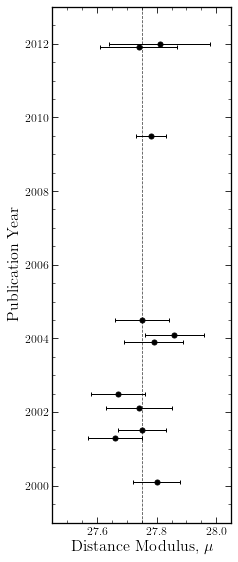

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Configuración de estilos científicos (Estilo ApJ / MNRAS)
plt.rcParams.update({
    "text.usetex": True,            # Renderizado LaTeX real
    "font.family": "serif",         # Familia de fuente académica
    "font.serif": ["Times New Roman", "Computer Modern Roman"],
    "font.size": 13,                # Tamaño base para el cuerpo del paper
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",        # Ticks apuntando hacia adentro
    "ytick.direction": "in",
    "xtick.top": True,              # Ticks en el marco superior
    "ytick.right": True,            # Ticks en el marco derecho
    "xtick.major.size": 6,          # Tamaño de los ticks principales
    "ytick.major.size": 6,
    "xtick.minor.size": 3,          # Tamaño de los ticks secundarios
    "ytick.minor.size": 3,
})

# 1. Datos aproximados extraídos de la imagen original
years = np.array([2000.1, 2001.3, 2001.5, 2002.1, 2002.5, 2003.9, 2004.1, 2004.5, 2009.5, 2011.9, 2012.0])
mu = np.array([27.80, 27.66, 27.75, 27.74, 27.67, 27.79, 27.86, 27.75, 27.78, 27.74, 27.81])
errors = np.array([0.08, 0.09, 0.08, 0.11, 0.09, 0.10, 0.10, 0.09, 0.05, 0.13, 0.17])

# Ajuste estético: En astrofísica se prefiere usar un solo color (o escala de grises) 
# a menos que el color represente una tercera variable física (ej. bandas de filtro).
# Usaremos círculos negros rellenos con bordes definidos para máxima claridad de impresión.
color_paper = 'black'

# 2. Configurar la figura vertical (dimensiones típicas de una columna de paper)
fig, ax = plt.subplots(figsize=(3.5, 8)) # Ajustado para maquetación standard de 1 columna

# Activar ticks secundarios automáticamente en ambos ejes
ax.minorticks_on()

# Línea de referencia central (Línea punteada fina, estilo científico)
ax.axvline(x=27.75, color='black', linestyle='--', linewidth=0.8, alpha=0.7)

# 3. Graficar los puntos con barras de error horizontales
for y, m, e in zip(years, mu, errors):
    ax.errorbar(
        x=m,          
        y=y,          
        xerr=e,       
        fmt='o', 
        color=color_paper, 
        markerfacecolor='black', # Puedes cambiar a 'white' si prefieres marcadores huecos
        markeredgecolor='black',
        ecolor=color_paper, 
        elinewidth=1.0,         # Líneas de error más delgadas y elegantes
        capsize=2,              # Remates de error más sutiles
        markersize=5
    )

# 4. Ajustes de formato y etiquetas con notación LaTeX
ax.set_xlim(27.45, 28.05)
ax.set_ylim(1999, 2013)

# Uso de entornos matemáticos de LaTeX ($...$) para las variables
ax.set_xlabel(r'Distance Modulus, $\mu$', fontsize=16)
ax.set_ylabel(r'Publication Year', fontsize=16)

# En formato paper se omiten las cuadrículas de fondo (grids) para evitar ruido visual,
# pero si decides mantenerla, una línea muy sutil es la norma:
# ax.grid(axis='x', linestyle=':', alpha=0.2, color='gray')

plt.tight_layout()
plt.savefig('CFH_mu_forest_plot.png', dpi=300, bbox_inches='tight', transparent = True) # Recomendado exportar en .pdf vectorizado para LaTeX
plt.show()


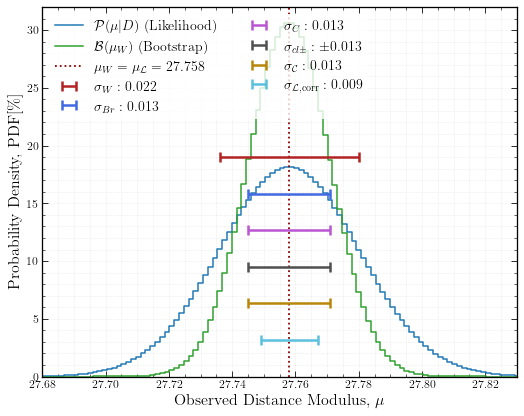

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Configuración de estilos científicos (Paper-like / ApJ / MNRAS)
plt.rcParams.update({
    "text.usetex": True,            # Renderizado LaTeX real
    "font.family": "serif",         # Tipografía académica
    "font.serif": ["Times New Roman", "Computer Modern Roman"],
    "font.size": 14,                
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",        # Ticks hacia adentro
    "ytick.direction": "in",
    "xtick.top": True,              # Marco superior con ticks
    "ytick.right": True,            # Marco derecho con ticks
    "xtick.major.size": 6,          
    "ytick.major.size": 6,
    "xtick.minor.size": 3,          
    "ytick.minor.size": 3,
})

# 1. Parámetros de las distribuciones basados en tu imagen
mu_val = 27.758
sigma_blue = 0.022   # Likelihood posterior (más ancha)
sigma_green = 0.013  # Bootstrap (más angosta y alta)

# Generar datos simulados que mantengan la estructura visual exacta
x = np.linspace(27.68, 27.83, 100)
# Ajustamos las amplitudes para que el pico verde llegue a ~30% y el azul a ~18%
pdf_blue = norm.pdf(x, mu_val, sigma_blue) * 1.0
pdf_green = norm.pdf(x, mu_val, sigma_green) * 1.0

# Inicializar gráfico
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.minorticks_on()

# 2. Dibujar las distribuciones con estilo 'step' (escalonado) de publicación
# Usamos colores sobrios o variantes académicas de la imagen original
ax.step(x, pdf_blue, where='mid', color='#1f77b4', linewidth=1.5, label=r'$\mathcal{P}(\mu|D)$ (Likelihood)')
ax.step(x, pdf_green, where='mid', color='#2ca02c', linewidth=1.5, label=r'$\mathcal{B}(\mu_W)$ (Bootstrap)')

# 3. Línea central (Media ponderada / Valor central)
ax.axvline(x=mu_val, color='#8b0000', linestyle=':', linewidth=1.8, label=r'$\mu_W = \mu_{\mathcal{L}} = 27.758$')

# 4. Graficar las barras horizontales de error/intervalos de confianza al 68%
# Definimos los valores de error (semiancho de la barra) y la altura en el eje Y donde se colocarán
errors_data = [
    {"label": r'$\sigma_W: 0.022$', "err": 0.022, "y_pos": 19.0, "color": '#b22222'},
    {"label": r'$\sigma_{Br}: 0.013$', "err": 0.013, "y_pos": 15.8, "color": '#4169e1'},
    {"label": r'$\sigma_C: 0.013$', "err": 0.013, "y_pos": 12.7, "color": '#ba55d3'},
    {"label": r'$\sigma_{cl\pm}: \pm0.013$', "err": 0.013, "y_pos": 9.5, "color": '#4f4f4f'},
    {"label": r'$\sigma_{\mathcal{C}}: 0.013$', "err": 0.013, "y_pos": 6.4, "color": '#b8860b'},
    {"label": r'$\sigma_{\mathcal{L},\mathrm{corr}}: 0.009$', "err": 0.009, "y_pos": 3.2, "color": '#5bc0de'}
]

for item in errors_data:
    ax.errorbar(
        x=mu_val, 
        y=item["y_pos"], 
        xerr=item["err"], 
        fmt='none',          # Sin punto central, solo la barra
        color=item["color"], 
        elinewidth=2.5,      # Barras gruesas como en la imagen para destacar
        capsize=5,           # Remates verticales de los extremos
        capthick=2.5,
        label=item["label"]
    )

# 5. Formato de ejes y leyendas científicas
ax.set_xlim(27.68, 27.83)
ax.set_ylim(0, 32)

ax.set_xlabel(r'Observed Distance Modulus, $\mu$', fontsize=16)
ax.set_ylabel(r'Probability Density, $\mathrm{PDF} [\%]$', fontsize=16)

# Grid muy tenue de fondo (característico de este tipo de plots de diagnóstico)
ax.grid(True, which='both', linestyle=':', linewidth=0.5, alpha=0.5)

# Organizar la leyenda en 2 columnas en la parte superior izquierda de manera limpia
ax.legend(loc='upper left', ncol=2, frameon=True, facecolor='white', edgecolor='none', fontsize=14)

plt.tight_layout()
# Guardar en PDF vectorizado listo para incluir en el archivo LaTeX del paper
plt.savefig('CFH_distance_modulus_pdf.png', dpi=300, bbox_inches='tight', transparent = True)
plt.show()


In [7]:
data_models = [
    # -------------------------------
    # Cosmological Model Dependent
    # -------------------------------
    {"group": "model", "label": "CMB (Planck)",  "H0": 67.4, "err": 0.5, "color": "forestgreen"},
    {"group": "model", "label": "CMB (WMAP + ACT)","H0": 67.6, "err": 1.1, "color": "green"},
    {"group": "model", "label": "CMB (WMAP + SPT)","H0": 68.2, "err": 1.1, "color": "green"},
    {"group": "model", "label": "DESI-DR1 BAO + BBN + " + r'${\theta}_{\star}$',"H0": 68.52, "err": 0.62, "color": "green"},
    {"group": "model", "label": "DESI-DR1 BAO + CMB","H0": 67.97, "err": 0.38, "color": "green"},
    {"group": "model", "label": "DESI-DR2 BAO + BBN + " + r'${\theta}_{\star}$',"H0": 68.45, "err": 0.47, "color": "green"},
    {"group": "model", "label": "DESI-DR2 BAO + CMB","H0": 68.17, "err": 0.28, "color": "green"},


    # -------------------------------
    # Direct (D vs z)
    # -------------------------------
    {"group": "direct", "label": r"SN Ia - Cepheids (S$H_0$ES/HST)","H0": 73.04, "err": 1.04, "color": "red"},
    {"group": "direct", "label": r"SN Ia - Cepheids (CCHP/JWST)","H0": 72.05, "err": 1.86, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - Cepheids (S$H_0$ES/HST)","H0": 73.40, "err": 2.10, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - Cepheids (S$H_0$ES/JWST)","H0": 73.20, "err": 0.90, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - TRGB (CCHP/HST)","H0": 69.80, "err": 0.80, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - TRGB (Anand et al./HST)","H0": 71.50, "err": 1.80, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - TRGB (CCHP/JWST)","H0": 69.85, "err": 1.75, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - JAGB (CCHP/JWST)","H0": 67.96, "err": 1.85, "color": "salmon"},

]

/tmp/ipykernel_10929/692496366.py:131: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(66.9, 67.9, color="#66A061", alpha=0.10, edgecolor='none')
/tmp/ipykernel_10929/692496366.py:132: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(72.0, 74.08, color="#EF6A6A", alpha=0.10, edgecolor='none')


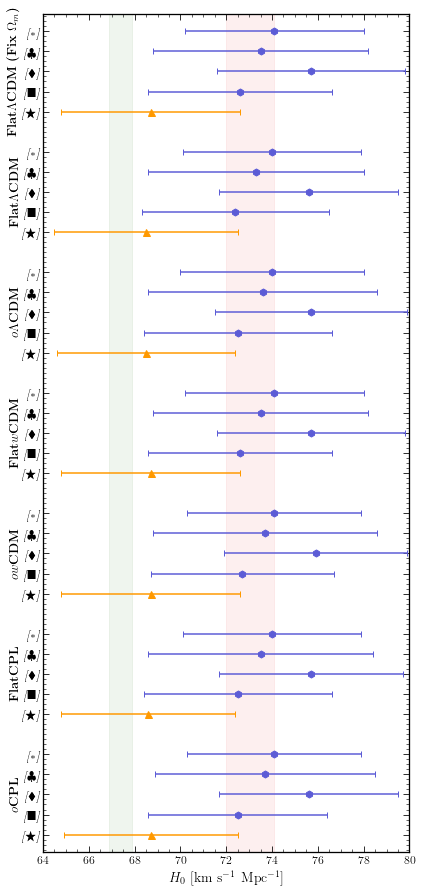

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración de estilo de publicación astrofísica (Paper-like)
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Computer Modern Roman"],
    "font.size": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "text.latex.preamble": r"\usepackage{amssymb}"
})

# =============================================================================
# CONFIGURACIÓN DE DATOS DINÁMICOS
# Puedes agregar, quitar o renombrar tantos grupos como desees aquí.
# Cada grupo DEBE contener exactamente 5 mediciones en 'values' y 'errors'.
# =============================================================================
data_groups = {
    "Flat$\Lambda$CDM (Fix $\Omega_m$)": {
        "values": [68.7, 72.6, 75.7, 73.5, 74.1],
        "errors": [3.9, 4.0, 4.1, 4.7, 3.9],
        "color": "#1f77b4"
    },
    "Flat$\Lambda$CDM": {
        "values": [68.5, 72.4, 75.6, 73.3, 74],
        "errors": [4.0, 4.1, 3.9, 4.7, 3.9],
        "color": "#2ca02c"
    },
    "$o\Lambda$CDM": {
        "values": [68.5, 72.5, 75.7, 73.6, 74],
        "errors": [3.9, 4.1, 4.2, 5.0, 4.0],
        "color": "#d62728"
    },
    "Flat$w$CDM": {
        "values": [68.7, 72.6, 75.7, 73.5, 74.1],
        "errors": [3.9, 4.0, 4.1, 4.7, 3.9],
        "color": "#d62728"
    },
    "$ow$CDM": {
        "values": [68.7, 72.7, 75.9, 73.7, 74.1],
        "errors": [3.9, 4.0, 4.0, 4.9, 3.8],
        "color": "#d62728"
    },
    "FlatCPL": {
        "values": [68.6, 72.5, 75.7, 73.5, 74],
        "errors": [3.8, 4.1, 4.0, 4.9, 3.9],
        "color": "#d62728"
    },
    "$o$CPL": {
        "values": [68.7, 72.5, 75.6, 73.7, 74.1],
        "errors": [3.8, 3.9, 3.9, 4.8, 3.8],
        "color": "#d62728"
    }
}

# Símbolos fijos para los 5 modelos de cada grupo
simbolos_base = [
    r"[$\bigstar$]",
    r"[$\blacksquare$]",
    r"[$\blacklozenge$]",
    r"[$\clubsuit$]",
    r"[$\ast$]"
]

# =============================================================================
# PROCESAMIENTO AUTOMÁTICO DE POSICIONES Y VECTORES
# =============================================================================
y_positions = []
all_values = []
all_errors = []
all_colors = []
all_markers = []  # Lista para almacenar los marcadores personalizados
subgrupos_labels = []
group_metadata = [] # Guardará (y_centro, nombre_grupo) para los textos de la izquierda

step_internal = 0.7  # Distancia fija entre los 5 modelos de un mismo grupo
step_group = 1.4     # Espacio libre de separación entre bloques de grupos
current_y = 0.0

# Procesar al revés (de abajo hacia arriba) para mantener el orden natural en el plot
for g_name, g_data in reversed(list(data_groups.items())):
    # Posiciones Y para los 5 modelos de este grupo
    g_y = current_y + np.arange(5) * step_internal
    y_positions.extend(g_y)
    
    # Acumular datos
    all_values.extend(g_data["values"])
    all_errors.extend(g_data["errors"])
    
    # Asignar colores y marcadores según la posición dentro del grupo (0 a 4)
    for i in range(5):
        if i >= 1:
            all_colors.append("#5c5cd6")  # Azul-violeta
            all_markers.append("h")        # Hexágono
        else:
            all_colors.append("#ff9900")  # Amarillo-naranja
            all_markers.append("^")        # Triángulo
            
    subgrupos_labels.extend(simbolos_base)
    
    # Calcular el centro geométrico del grupo para la etiqueta de la izquierda
    y_centro = (g_y[0] + g_y[-1]) / 2.0
    group_metadata.append((y_centro, g_name))
    
    # Actualizar el punto de partida Y para el siguiente grupo (con el espacio intergrupo)
    current_y = g_y[-1] + step_group

y_positions = np.array(y_positions)

# =============================================================================
# CREACIÓN DEL GRÁFICO
# =============================================================================
# Ajuste dinámico de la altura: ~2.2 pulgadas base + 1.5 pulgadas por cada grupo
num_groups = len(data_groups)
fig_height = 2.2 + (num_groups * 1.5)
fig, ax = plt.subplots(figsize=(6, fig_height))
ax.minorticks_on()

# 1. Graficar bandas de fondo dinámicas para los rangos de consenso de cada grupo
ax.axvspan(66.9, 67.9, color="#66A061", alpha=0.10, edgecolor='none')
ax.axvspan(72.0, 74.08, color="#EF6A6A", alpha=0.10, edgecolor='none')


# 2. Graficar los puntos con barras de error horizontales
for y, val, err, col, mrk in zip(y_positions, all_values, all_errors, all_colors, all_markers):
    ax.errorbar(
        x=val, y=y, xerr=err, fmt=mrk, color=col, 
        markerfacecolor=col, markeredgecolor=col, ecolor=col, 
        elinewidth=1.5, capsize=3, markersize=7
    )

# 3. Ajustes de formato de los límites del recuadro
ax.set_xlim(64, 80)
# Límites holgados en Y basados en la posición de la última medición
ax.set_ylim(y_positions[0] - 0.6, y_positions[-1] + 0.6)

# 4. Asignar los símbolos tipográficos al eje Y
ax.set_yticks(y_positions)
ax.set_yticklabels([rf"\textit{{ {s} }}" for s in subgrupos_labels])

# 5. Insertar los textos de los Grupos Principales a la izquierda de forma dinámica
for y_c, g_name in group_metadata:
    ax.text(
        63, y_c, rf"\textbf{{{g_name}}}", 
        fontsize=13, fontweight='bold', va='center', ha='right', rotation=90
    )

# Etiqueta del eje X
ax.set_xlabel(r"$H_0 \ [\mathrm{km \ s^{-1} \ Mpc^{-1}}]$", fontsize=14)

plt.tight_layout()
plt.savefig('CFH_cosmo_nested_forest_plot.png', dpi=300, bbox_inches='tight')
plt.show()


/home/hollman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/chains/wCDM/planck_hiig_cepheids.2.txt
/home/hollman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/chains/wCDM/planck_hiig_cepheids.1.txt
/home/hollman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/chains/wCDM/planck_hiig_cepheids.3.txt
/home/hollman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/chains/wCDM/planck_hiig_cepheids.4.txt
Removed 0.3 as burn in

Parámetros disponibles:

logA     \log(10^{10}A_s)
n_s     n_s
omega_b     \Omega_b h^2
tau_reio     \tau_{\rm reio}
alpha_ls     \alpha_{L\sigma}
beta_ls     \beta_{L\sigma}
H0     H_0
Omega_m     \Omega_m
w0_fld     w_{\rm DE}
A_planck     y_\mathrm{cal}
A_s     A_s
chi2__CMB     \chi^2_\mathrm{CMB}
minuslogprior     -\log\pi
minuslogprior__0     -\log\pi_\mathrm{0}
chi2     \chi^2
chi2__planck_2018_lowl.TT     \chi^2_\mathrm{planck\ 2018\ lowl.TT}
chi2__planck_2018_lowl.EE     \chi^2_\mathrm{

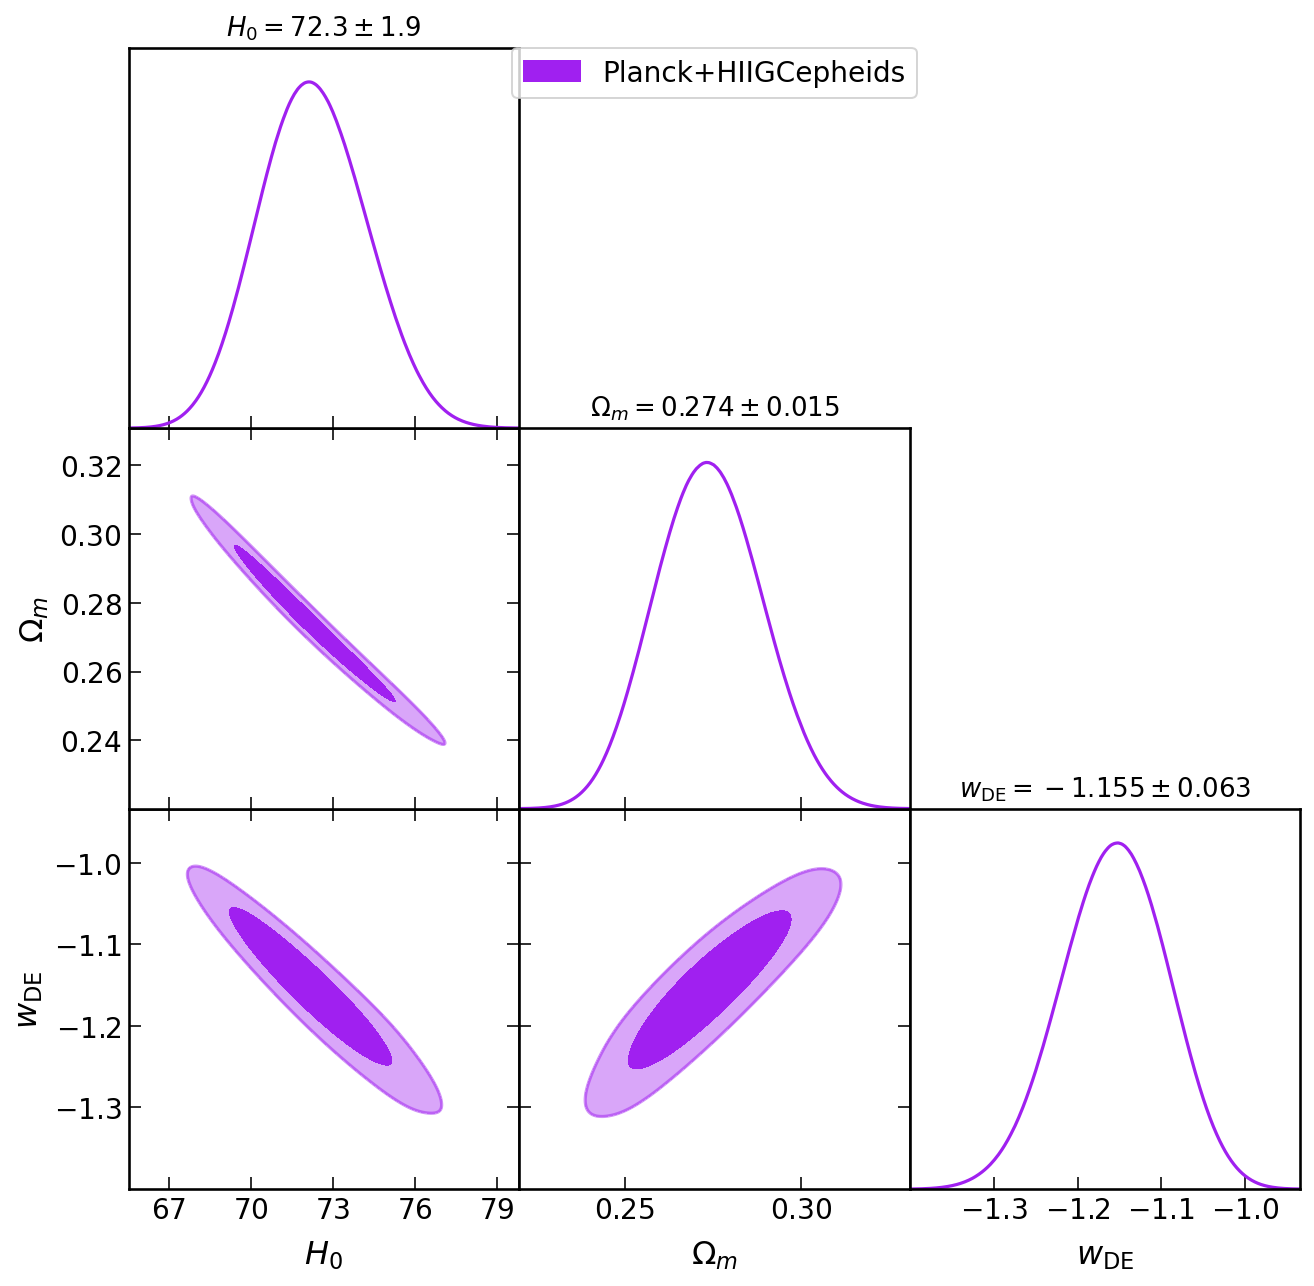

In [9]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from getdist import plots, loadMCSamples
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# ============================================================
# 1. CONFIGURACIÓN GRÁFICA
# ============================================================
font = {
    'size': 15,
    'family': 'sans-serif'
}
matplotlib.rc('font', **font)
plt.rcParams["text.usetex"] = False
# Compatibilidad con algunas versiones/código antiguo
np.infty = np.inf
# ============================================================
# 2. DIRECTORIO DE LAS CADENAS
# ============================================================
root_path = os.path.expanduser('~/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/')
chain_root = os.path.join(
    root_path,
    'chains/wCDM/planck_hiig_cepheids'
)
# ============================================================
# 3. CARGAR CADENA
# ============================================================
samples = loadMCSamples(
    chain_root,
    settings={
        'ignore_rows': 0.3,
        'smooth_scale_1D': 0.6,
        'smooth_scale_2D': 0.6
    },
    no_cache=True
)
params = samples.getParams()
# ============================================================
# 4. VER QUÉ PARÁMETROS EXISTEN
# ============================================================
print("\nParámetros disponibles:\n")
for p in samples.getParamNames().names:
    print(p.name, "   ", p.label)

# ============================================================
# 5. PARÁMETROS DERIVADOS
# ============================================================
samples.addDerived(
    params.H0 / 100.0,
    name='h',
    label='h'
)
q0 = (
    0.5 * params.Omega_m
    + 0.5 * (1.0 + 3.0 * params.w0_fld)
    * (1.0 - params.Omega_m)
)
samples.addDerived(
    q0,
    name='q0',
    label='q_0'
)

# ============================================================
# 6. TABLA DE RESULTADOS
# ============================================================
main_params = [
    'H0',
    'Omega_m',
    'w0_fld',
    'alpha_ls',
    'beta_ls'
]
print(
    samples.getTable(
        limit=1,
        paramList=main_params
    ).tableTex()
)
print(
    samples.getTable(
        limit=2,
        paramList=main_params
    ).tableTex()
)
# ============================================================
# 7. LIKELIHOOD STATISTICS
# ============================================================
print(samples.getLikeStats())
stats = samples.getMargeStats()
for name in main_params:
    par = stats.parWithName(name)
    print(
        f"{name:10s} : "
        f"{par.mean:.5f} "
        f"+{par.limits[0].upper - par.mean:.5f} "
        f"{par.limits[0].lower - par.mean:.5f}"
    )
# ============================================================
# 8. TRIANGLE PLOT COSMOLÓGICO
# ============================================================
g = plots.get_subplot_plotter(
    subplot_size=3.5
)
g.settings.axes_fontsize = 14
g.settings.lab_fontsize = 16
g.settings.legend_fontsize = 14
g.settings.title_limit_fontsize = 13
g.triangle_plot(
    [samples],
    ['H0', 'Omega_m', 'w0_fld'],
    filled=True,
    shaded=False,
    legend_labels=[
        r"Planck+HIIGCepheids"
    ],
    contour_colors=[
        '#A020F0'
    ],
    contour_lws=1.6,
    title_limit=1,
    legend_loc='upper center' 
)
plt.savefig(
    'CFH_Planck_HIIG_Cepheids_wCDM_cosmology.png',
    bbox_inches='tight', transparent = True,dpi=300,
)
plt.show()

/home/hollman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/chains/wCDM/planck_hiig_trgb.2.txt
/home/hollman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/chains/wCDM/planck_hiig_trgb.4.txt
/home/hollman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/chains/wCDM/planck_hiig_trgb.1.txt
/home/hollman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/chains/wCDM/planck_hiig_trgb.3.txt
Removed 0.3 as burn in

Parámetros disponibles:

logA     \log(10^{10}A_s)
n_s     n_s
omega_b     \Omega_b h^2
tau_reio     \tau_{\rm reio}
alpha_ls     \alpha_{L\sigma}
beta_ls     \beta_{L\sigma}
H0     H_0
Omega_m     \Omega_m
w0_fld     w_{\rm DE}
A_planck     y_\mathrm{cal}
A_s     A_s
chi2__CMB     \chi^2_\mathrm{CMB}
minuslogprior     -\log\pi
minuslogprior__0     -\log\pi_\mathrm{0}
chi2     \chi^2
chi2__planck_2018_lowl.TT     \chi^2_\mathrm{planck\ 2018\ lowl.TT}
chi2__planck_2018_lowl.EE     \chi^2_\mathrm{planck\ 2018\ lo

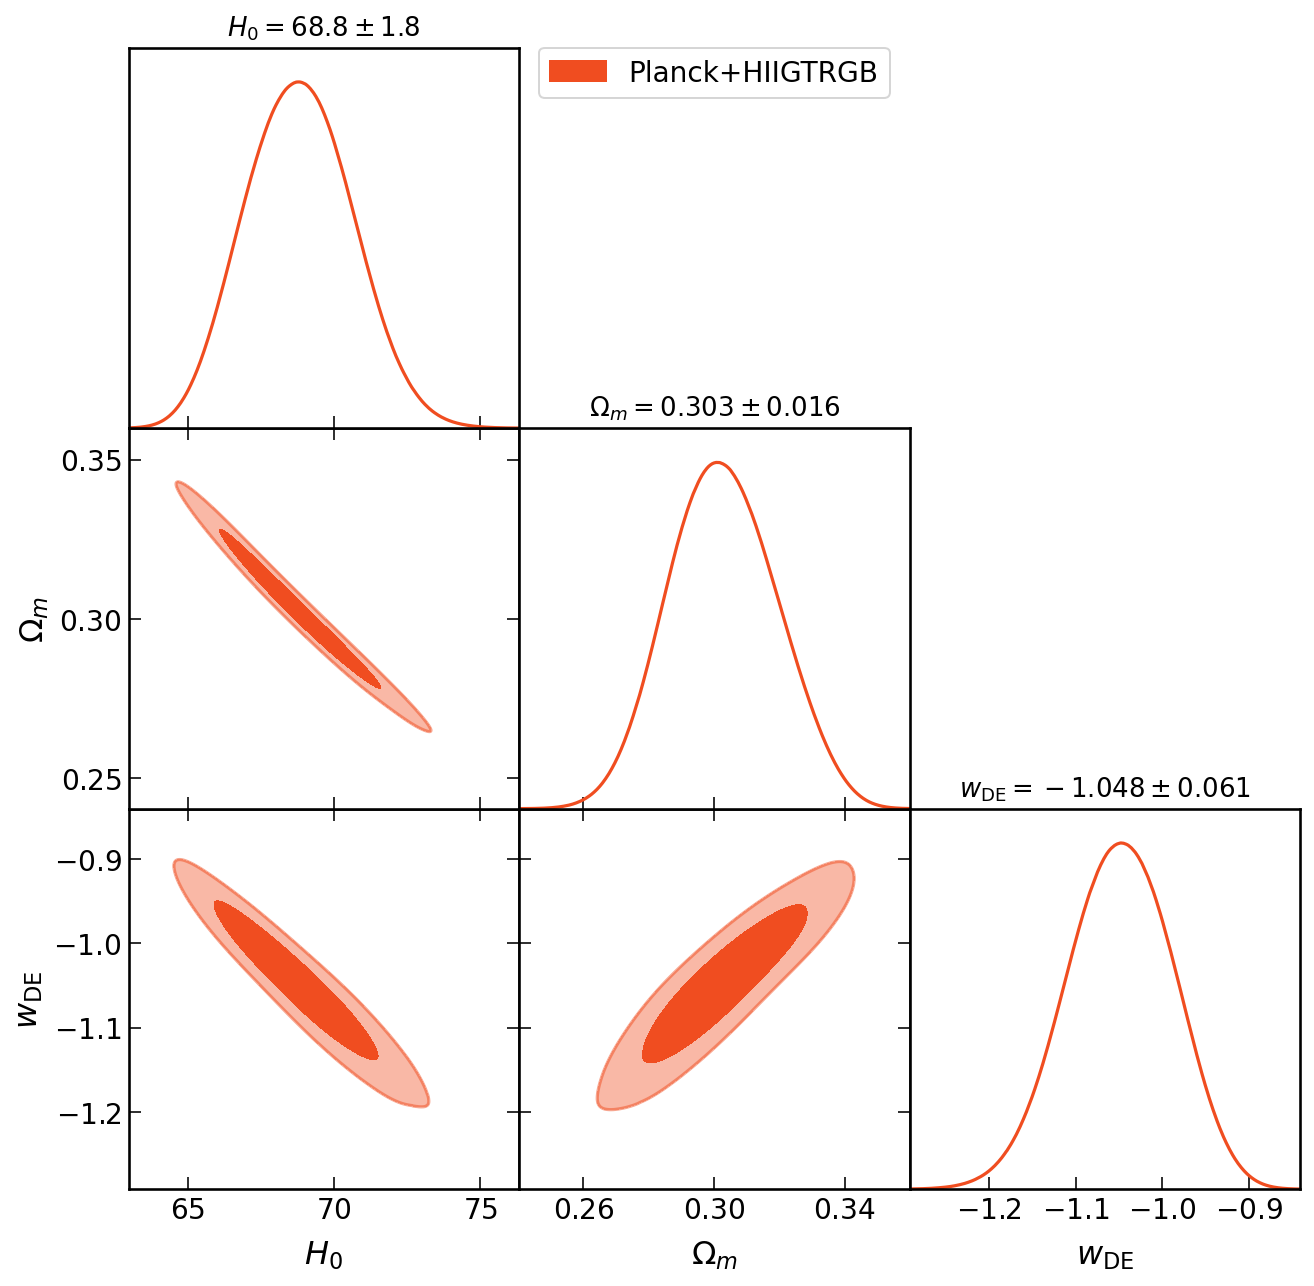

In [10]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from getdist import plots, loadMCSamples
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# ============================================================
# 1. CONFIGURACIÓN GRÁFICA
# ============================================================
font = {
    'size': 15,
    'family': 'sans-serif'
}
matplotlib.rc('font', **font)
plt.rcParams["text.usetex"] = False
# Compatibilidad con algunas versiones/código antiguo
np.infty = np.inf
# ============================================================
# 2. DIRECTORIO DE LAS CADENAS
# ============================================================
root_path = os.path.expanduser('~/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/')
chain_root = os.path.join(
    root_path,
    'chains/wCDM/planck_hiig_trgb'
)
# ============================================================
# 3. CARGAR CADENA
# ============================================================
samples = loadMCSamples(
    chain_root,
    settings={
        'ignore_rows': 0.3,
        'smooth_scale_1D': 0.6,
        'smooth_scale_2D': 0.6
    },
    no_cache=True
)
params = samples.getParams()
# ============================================================
# 4. VER QUÉ PARÁMETROS EXISTEN
# ============================================================
print("\nParámetros disponibles:\n")
for p in samples.getParamNames().names:
    print(p.name, "   ", p.label)

# ============================================================
# 5. PARÁMETROS DERIVADOS
# ============================================================
samples.addDerived(
    params.H0 / 100.0,
    name='h',
    label='h'
)
q0 = (
    0.5 * params.Omega_m
    + 0.5 * (1.0 + 3.0 * params.w0_fld)
    * (1.0 - params.Omega_m)
)
samples.addDerived(
    q0,
    name='q0',
    label='q_0'
)

# ============================================================
# 6. TABLA DE RESULTADOS
# ============================================================
main_params = [
    'H0',
    'Omega_m',
    'w0_fld',
    'alpha_ls',
    'beta_ls'
]
print(
    samples.getTable(
        limit=1,
        paramList=main_params
    ).tableTex()
)
print(
    samples.getTable(
        limit=2,
        paramList=main_params
    ).tableTex()
)
# ============================================================
# 7. LIKELIHOOD STATISTICS
# ============================================================
print(samples.getLikeStats())
stats = samples.getMargeStats()
for name in main_params:
    par = stats.parWithName(name)
    print(
        f"{name:10s} : "
        f"{par.mean:.5f} "
        f"+{par.limits[0].upper - par.mean:.5f} "
        f"{par.limits[0].lower - par.mean:.5f}"
    )
# ============================================================
# 8. TRIANGLE PLOT COSMOLÓGICO
# ============================================================
g = plots.get_subplot_plotter(
    subplot_size=3.5
)
g.settings.axes_fontsize = 14
g.settings.lab_fontsize = 16
g.settings.legend_fontsize = 14
g.settings.title_limit_fontsize = 13
g.triangle_plot(
    [samples],
    ['H0', 'Omega_m', 'w0_fld'],
    filled=True,
    shaded=False,
    legend_labels=[
        r"Planck+HIIGTRGB"
    ],
    contour_colors=[
        "#F04D20"
    ],
    contour_lws=1.6,
    title_limit=1,
    legend_loc='upper center' 
)
plt.savefig(
    'CFH_Planck_HIIG_TRGB_wCDM_cosmology.png',
    bbox_inches='tight', transparent = True,dpi=300,
)
plt.show()

/home/hollman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/chains/w0waCDM/planck_hiig_cepheids.2.txt
/home/hollman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/chains/w0waCDM/planck_hiig_cepheids.1.txt
/home/hollman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/chains/w0waCDM/planck_hiig_cepheids.3.txt
/home/hollman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/chains/w0waCDM/planck_hiig_cepheids.4.txt
Removed 0.3 as burn in

Parámetros disponibles:

logA     \log(10^{10}A_s)
n_s     n_s
omega_b     \Omega_b h^2
tau_reio     \tau_{\rm reio}
alpha_ls     \alpha_{L\sigma}
beta_ls     \beta_{L\sigma}
H0     H_0
Omega_m     \Omega_m
w0_fld     w_0
wa_fld     w_a
A_planck     y_\mathrm{cal}
A_s     A_s
chi2__CMB     \chi^2_\mathrm{CMB}
minuslogprior     -\log\pi
minuslogprior__0     -\log\pi_\mathrm{0}
chi2     \chi^2
chi2__planck_2018_lowl.TT     \chi^2_\mathrm{planck\ 2018\ lowl.TT}
chi2__planck_2018_lowl.EE

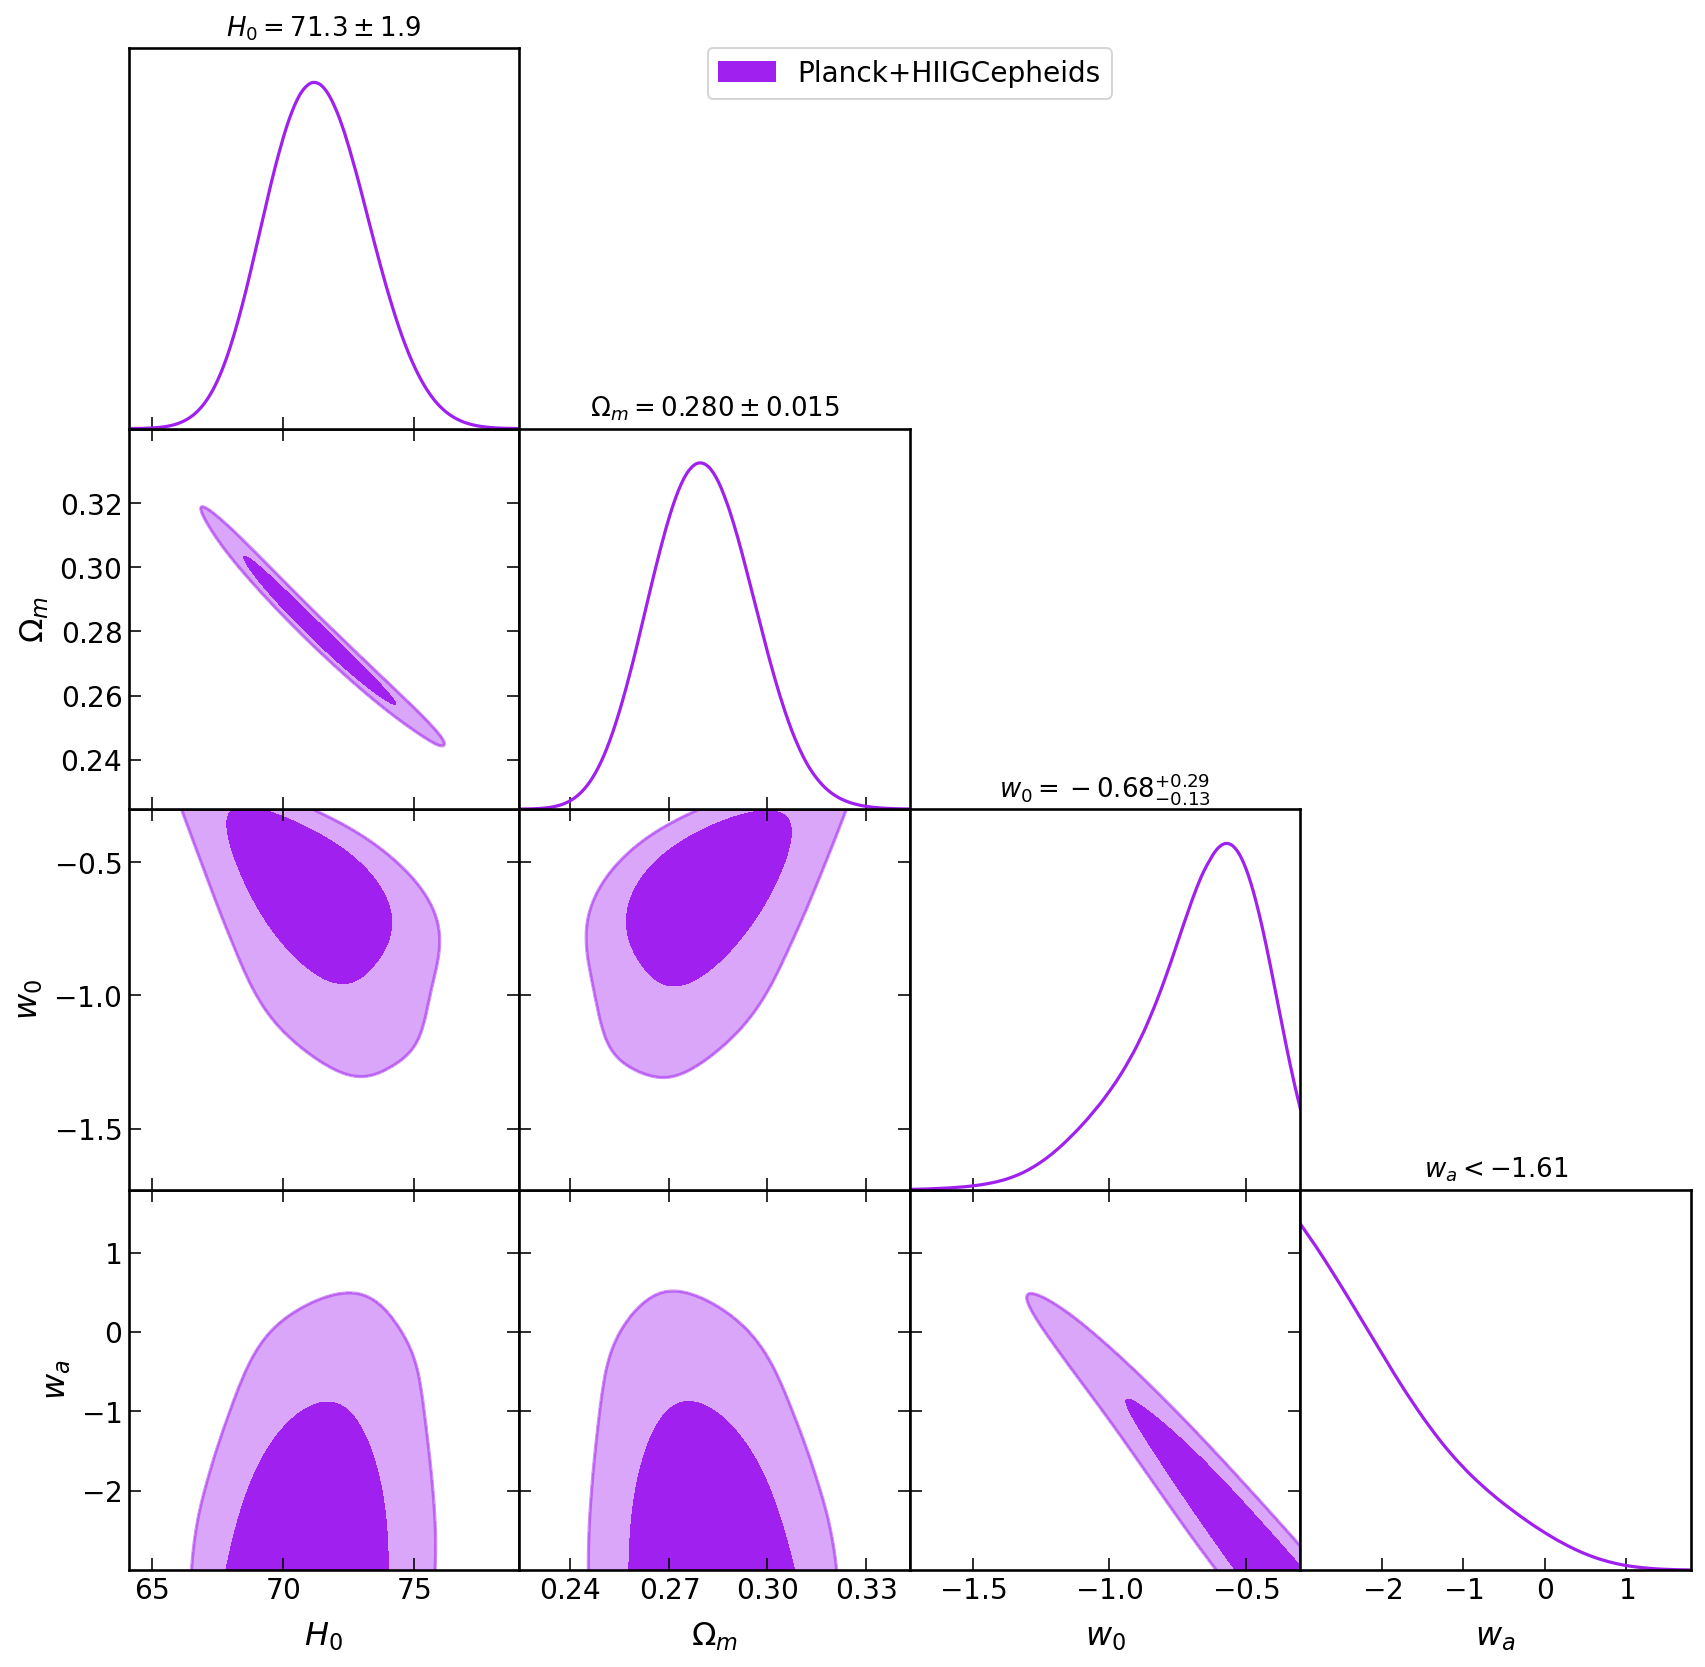

In [11]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from getdist import plots, loadMCSamples
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# ============================================================
# 1. CONFIGURACIÓN GRÁFICA
# ============================================================
font = {
    'size': 15,
    'family': 'sans-serif'
}
matplotlib.rc('font', **font)
plt.rcParams["text.usetex"] = False
# Compatibilidad con algunas versiones/código antiguo
np.infty = np.inf
# ============================================================
# 2. DIRECTORIO DE LAS CADENAS
# ============================================================
root_path = os.path.expanduser('~/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/')
chain_root = os.path.join(
    root_path,
    'chains/w0waCDM/planck_hiig_cepheids'
)
# ============================================================
# 3. CARGAR CADENA
# ============================================================
samples = loadMCSamples(
    chain_root,
    settings={
        'ignore_rows': 0.3,
        'smooth_scale_1D': 0.6,
        'smooth_scale_2D': 0.6
    },
    no_cache=True
)
params = samples.getParams()
# ============================================================
# 4. VER QUÉ PARÁMETROS EXISTEN
# ============================================================
print("\nParámetros disponibles:\n")
for p in samples.getParamNames().names:
    print(p.name, "   ", p.label)

# ============================================================
# 5. PARÁMETROS DERIVADOS
# ============================================================
samples.addDerived(
    params.H0 / 100.0,
    name='h',
    label='h'
)
q0 = (
    0.5 * params.Omega_m
    + 0.5 * (1.0 + 3.0 * params.w0_fld)
    * (1.0 - params.Omega_m)
)
samples.addDerived(
    q0,
    name='q0',
    label='q_0'
)

# ============================================================
# 6. TABLA DE RESULTADOS
# ============================================================
main_params = [
    'H0',
    'Omega_m',
    'w0_fld',
    'wa_fld',
    'alpha_ls',
    'beta_ls'
]
print(
    samples.getTable(
        limit=1,
        paramList=main_params
    ).tableTex()
)
print(
    samples.getTable(
        limit=2,
        paramList=main_params
    ).tableTex()
)
# ============================================================
# 7. LIKELIHOOD STATISTICS
# ============================================================
print(samples.getLikeStats())
stats = samples.getMargeStats()
for name in main_params:
    par = stats.parWithName(name)
    print(
        f"{name:10s} : "
        f"{par.mean:.5f} "
        f"+{par.limits[0].upper - par.mean:.5f} "
        f"{par.limits[0].lower - par.mean:.5f}"
    )
# ============================================================
# 8. TRIANGLE PLOT COSMOLÓGICO
# ============================================================
g = plots.get_subplot_plotter(
    subplot_size=3.5
)
g.settings.axes_fontsize = 14
g.settings.lab_fontsize = 16
g.settings.legend_fontsize = 14
g.settings.title_limit_fontsize = 13
g.triangle_plot(
    [samples],
    ['H0', 'Omega_m', 'w0_fld', 'wa_fld'],
    filled=True,
    shaded=False,
    legend_labels=[
        r"Planck+HIIGCepheids"
    ],
    contour_colors=[
        '#A020F0'
    ],
    contour_lws=1.6,
    title_limit=1,
    legend_loc='upper center' 
)
plt.savefig(
    'CFH_Planck_HIIG_Cepheids_w0waCDM_cosmology.png',
    bbox_inches='tight', transparent = True,dpi=300,
)
plt.show()

/home/hollman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/chains/w0waCDM/planck_hiig_trgb.2.txt
/home/hollman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/chains/w0waCDM/planck_hiig_trgb.4.txt
/home/hollman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/chains/w0waCDM/planck_hiig_trgb.1.txt
/home/hollman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/chains/w0waCDM/planck_hiig_trgb.3.txt
Removed 0.3 as burn in

Parámetros disponibles:

logA     \log(10^{10}A_s)
n_s     n_s
omega_b     \Omega_b h^2
tau_reio     \tau_{\rm reio}
alpha_ls     \alpha_{L\sigma}
beta_ls     \beta_{L\sigma}
H0     H_0
Omega_m     \Omega_m
w0_fld     w_0
wa_fld     w_a
A_planck     y_\mathrm{cal}
A_s     A_s
chi2__CMB     \chi^2_\mathrm{CMB}
minuslogprior     -\log\pi
minuslogprior__0     -\log\pi_\mathrm{0}
chi2     \chi^2
chi2__planck_2018_lowl.TT     \chi^2_\mathrm{planck\ 2018\ lowl.TT}
chi2__planck_2018_lowl.EE     \chi^2_\mat

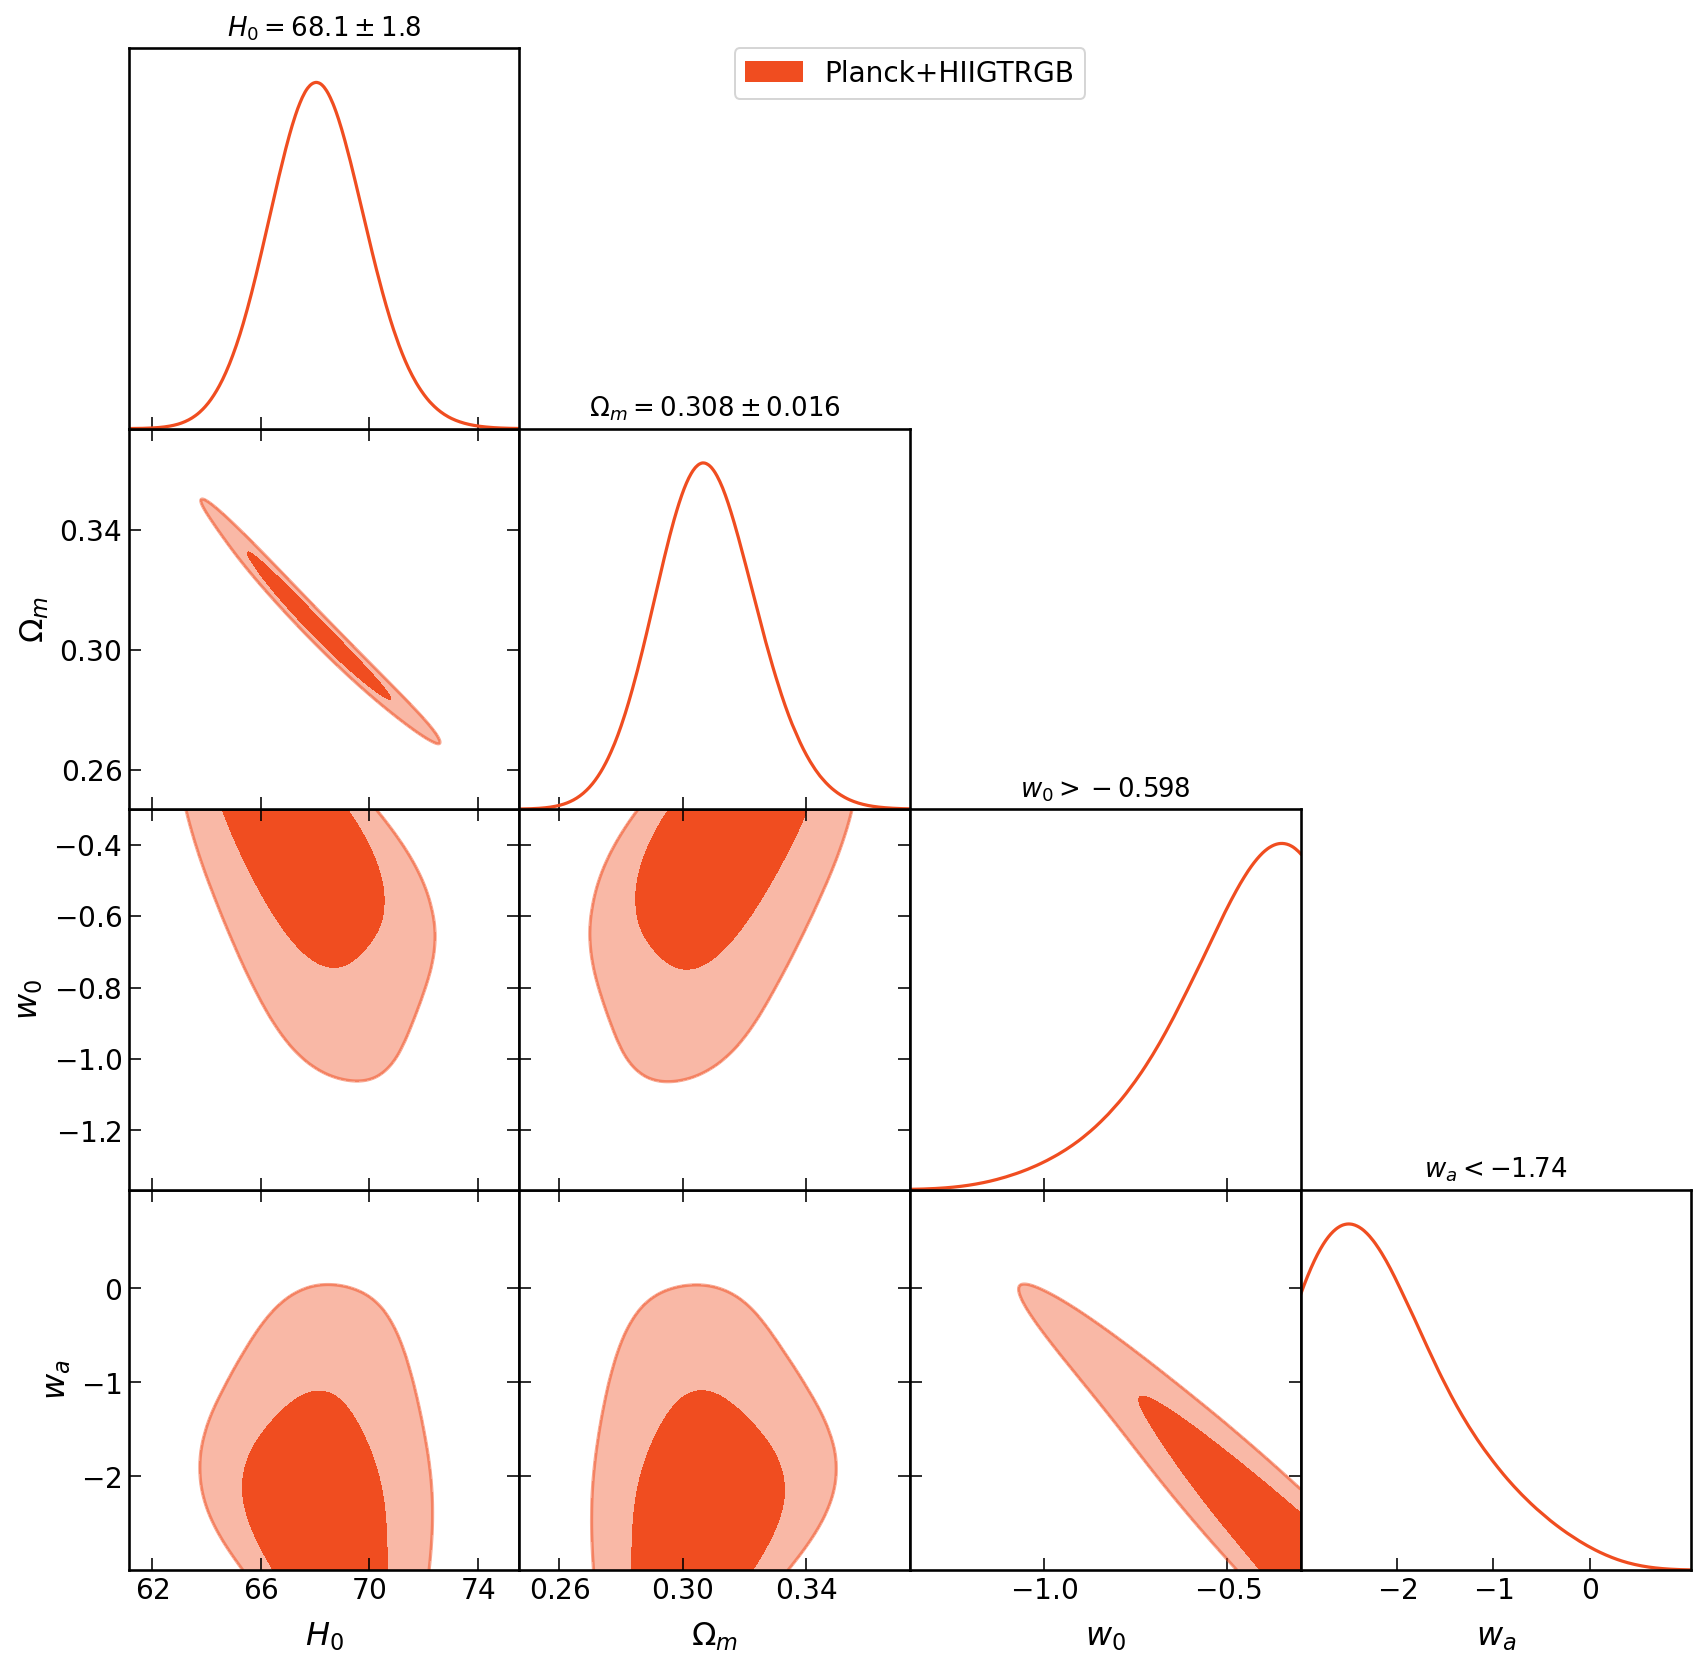

In [12]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from getdist import plots, loadMCSamples
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# ============================================================
# 1. CONFIGURACIÓN GRÁFICA
# ============================================================
font = {
    'size': 15,
    'family': 'sans-serif'
}
matplotlib.rc('font', **font)
plt.rcParams["text.usetex"] = False
# Compatibilidad con algunas versiones/código antiguo
np.infty = np.inf
# ============================================================
# 2. DIRECTORIO DE LAS CADENAS
# ============================================================
root_path = os.path.expanduser('~/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/')
chain_root = os.path.join(
    root_path,
    'chains/w0waCDM/planck_hiig_trgb'
)
# ============================================================
# 3. CARGAR CADENA
# ============================================================
samples = loadMCSamples(
    chain_root,
    settings={
        'ignore_rows': 0.3,
        'smooth_scale_1D': 0.6,
        'smooth_scale_2D': 0.6
    },
    no_cache=True
)
params = samples.getParams()
# ============================================================
# 4. VER QUÉ PARÁMETROS EXISTEN
# ============================================================
print("\nParámetros disponibles:\n")
for p in samples.getParamNames().names:
    print(p.name, "   ", p.label)

# ============================================================
# 5. PARÁMETROS DERIVADOS
# ============================================================
samples.addDerived(
    params.H0 / 100.0,
    name='h',
    label='h'
)
q0 = (
    0.5 * params.Omega_m
    + 0.5 * (1.0 + 3.0 * params.w0_fld)
    * (1.0 - params.Omega_m)
)
samples.addDerived(
    q0,
    name='q0',
    label='q_0'
)

# ============================================================
# 6. TABLA DE RESULTADOS
# ============================================================
main_params = [
    'H0',
    'Omega_m',
    'w0_fld',
    'wa_fld',
    'alpha_ls',
    'beta_ls'
]
print(
    samples.getTable(
        limit=1,
        paramList=main_params
    ).tableTex()
)
print(
    samples.getTable(
        limit=2,
        paramList=main_params
    ).tableTex()
)
# ============================================================
# 7. LIKELIHOOD STATISTICS
# ============================================================
print(samples.getLikeStats())
stats = samples.getMargeStats()
for name in main_params:
    par = stats.parWithName(name)
    print(
        f"{name:10s} : "
        f"{par.mean:.5f} "
        f"+{par.limits[0].upper - par.mean:.5f} "
        f"{par.limits[0].lower - par.mean:.5f}"
    )
# ============================================================
# 8. TRIANGLE PLOT COSMOLÓGICO
# ============================================================

g = plots.get_subplot_plotter(
    subplot_size=3.5
)


g.settings.axes_fontsize = 14
g.settings.lab_fontsize = 16
g.settings.legend_fontsize = 14
g.settings.title_limit_fontsize = 13
g.triangle_plot(
    [samples],
    ['H0', 'Omega_m', 'w0_fld', 'wa_fld'],
    filled=True,
    shaded=False,
    legend_labels=[
        r"Planck+HIIGTRGB"
    ],
    contour_colors=[
        '#F04D20'
    ],
    contour_lws=1.6,
    title_limit=1,
    legend_loc='upper center' 
)
plt.savefig(
    'CFH_Planck_HIIG_TRGB_w0waCDM_cosmology.png',
    bbox_inches='tight', transparent = True,dpi=300,
)
plt.show()

In [13]:
import ast
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar el archivo CSV principal
csv_path = "jobs.csv"  # Cambia esto por la ruta de tu CSV
df_base = pd.read_csv(csv_path)

# Lista para almacenar los datos de cada archivo
lista_resultados = []

# 2. Iterar sobre las filas del CSV para leer cada archivo "Results.txt"
for idx, row in df_base.iterrows():
    folder = row["folder_name"]
    prefix = row["id_prefix"]
    DATA_SET = row["distance_estimator_set"]
    Z_MAX = row["zmax"]

    # Construir la ruta dinámica del archivo
    file_path = f"{folder}/{prefix}" + "_Results.txt"

    # Verificar si el archivo existe para evitar errores
    if os.path.exists(file_path):
        with open(file_path) as f: #"text", encoding="utf-8"
            contenido = f.read()

            try:
                # Convertir el texto del diccionario en un objeto de Python
                datos_dict = ast.literal_eval(contenido.strip())

                datos_limpios = {
                    key: value[0] if isinstance(value, list) else value
                    for key, value in datos_dict.items()
                }

                datos_limpios["id_prefix"] = prefix
                datos_limpios["data_set"] = DATA_SET
                datos_limpios["zmax"] = Z_MAX


                nombre_carpeta = os.path.basename(os.path.normpath(folder))
                datos_limpios["folder"] = nombre_carpeta.split("_", 1)[0]

                lista_resultados.append(datos_limpios)

            except (ValueError, SyntaxError):
                print(f"Error al parsear el diccionario en: {file_path}")
    else:
        print(f"Archivo no encontrado: {file_path}")

# 3. Crear el DataFrame final con los resultados consolidados
df_final = pd.DataFrame(lista_resultados)

# Reordenar columnas para que id_prefix quede al principio
columnas = ["id_prefix"] + [col for col in df_final.columns if col != "id_prefix"]
df_final = df_final[columnas]

Main = df_final[(df_final["folder"] == 'Main')] # & (df_final["zmax"].isna())]
Liter = df_final[(df_final["folder"] == 'Liter')] # & (df_final["zmax"].isna())]
MockA = df_final[(df_final["folder"] == 'MockA')] # & (df_final["zmax"].isna())]
MockB = df_final[(df_final["folder"] == 'MockB')] # & (df_final["zmax"].isna())]
MockC = df_final[(df_final["folder"] == 'MockC')] # & (df_final["zmax"].isna())]
MockD = df_final[(df_final["folder"] == 'MockD')] # & (df_final["zmax"].isna())]
MockE = df_final[(df_final["folder"] == 'MockE')] # & (df_final["zmax"].isna())]


ValueError: 
\blacklozenge
^
ParseFatalException: Unknown symbol: \blacklozenge, found '\'  (at char 0), (line:1, col:1)

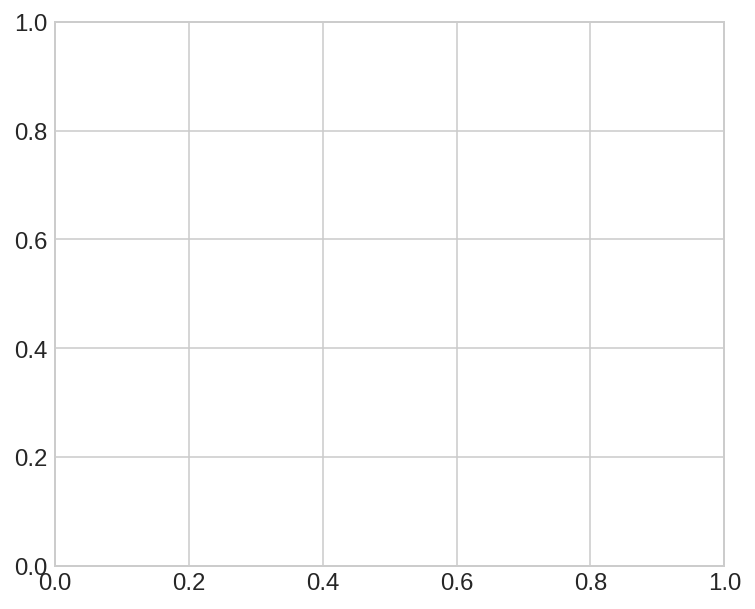

In [14]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker

# Configurar estilo general más limpio y tipografía profesional
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(6, 5))

# 1. Configuración de diccionarios de estilos (con colores más modernos)
markers_sets = {
    'sm_r.csv': r"$\ast$",      # square
    'sm_t.csv': r"$\clubsuit$",      # circle
    'cm_r.csv': r"$\blacklozenge$",      # diamond
    'cm_t.csv': r"$\blacksquare$",      # triangle up
    't_r.csv': r"$\bigstar$"        # triangle down
}

markers_sets2 = {
    'Ceph. SinZ. Eran': r"$\ast$",      # square
    'Ceph. SinZ. Etot': r"$\clubsuit$",      # circle
    'Ceph. ConZ. Eran': r"$\blacklozenge$",      # diamond
    'Ceph. ConZ. Etot': r"$\blacksquare$",      # triangle up
    'TRGB. Eran': r"$\bigstar$"        # triangle down
}

# Diccionario de grupos con colores refinados (hex codes)
group_styles = {
    'Main': {'color': '#1f77b4', 'edgecolor': '#0f3d59'},
    'Liter': {'color': '#d62728', 'edgecolor': '#6b1313'},
    'MockA': {'color': '#2ca02c', 'edgecolor': '#134713'},
    'MockB': {'color': '#9467bd', 'edgecolor': '#492f5e'},
    'MockC': {'color': '#8c564b', 'edgecolor': '#422722'},
    'MockD': {'color': '#ff7f0e', 'edgecolor': '#803f07'},
    'MockE': {'color': '#ffffff', 'edgecolor': '#333333'}
}

dfs = {
    'Main': Main, 'Liter': Liter, 'MockA': MockA, 
    'MockB': MockB, 'MockC': MockC, 'MockD': MockD, 'MockE': MockE
}

# 2. Graficar con transparencia (alpha) para evitar solapamientos opacos
for group_name, df in dfs.items():
    style = group_styles[group_name]
    for dataset_name, group in df.groupby('data_set'):
        marker_style = markers_sets.get(dataset_name, 'o')
        ax.scatter(
            group['GEHR'], group['h_e'],
            marker=marker_style,
            color=style['color'],
            edgecolor=style['edgecolor'],
            s=55,           # Tamaño optimizado de los marcadores
            alpha=0.85,     # Transparencia científica
            linewidth=1.2   # Grosor del borde del marcador
        )

# 3. Creación de leyendas profesionales
color_legends = [
    Line2D([0], [0], marker='o', color='w', 
           markerfacecolor=st['color'], markeredgecolor=st['edgecolor'], 
           markersize=8, label=name) 
    for name, st in group_styles.items()
]

marker_legends = [
    Line2D([0], [0], marker=m, color='w', 
           markerfacecolor='#666666', markeredgecolor='#111111', 
           markersize=8, label=d.replace('.csv', '')) 
    for d, m in markers_sets2.items()
]

# Añadir las leyendas al gráfico de forma ordenada
first_legend = ax.legend(handles=color_legends, title="Datasets", loc='upper left', bbox_to_anchor=(0.72, 1.1), frameon=True)
ax.add_artist(first_legend)
ax.legend(handles=marker_legends, title="Groups", loc='upper left', bbox_to_anchor=(0.3, 1.1), frameon=True)

# 4. Etiquetas y limpieza de ejes
ax.set_xlabel('Number of GEHR', fontsize=12, fontweight='bold')
ax.set_ylabel(r'$h$ error', fontsize=12, fontweight='bold')
ax.tick_params(labelsize=10)

# Quitar bordes innecesarios (Spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))


plt.savefig('CFH_mocked.png', dpi=300, bbox_inches='tight', transparent = True)
#plt.tight_layout()
plt.show()

{0.2: {'nometal': [(74.3, 4.1), (73.8, 5.2)],
       'metal': [(75.8, 4.3), (72.5, 4.3)],
       'trgb': [(69.0, 4.2)]},
 1.5: {'nometal': [(72.8, 4.0), (71.8, 5.0)],
       'metal': [(74.2, 4.2), (71.0, 4.2)],
       'trgb': [(67.2, 4.0)]},
 14: {'nometal': [(73.5, 3.7), (72.9, 4.7)],
      'metal': [(75.6, 3.9), (72.6, 3.9)],
      'trgb': [(67.6, 3.7)]}}


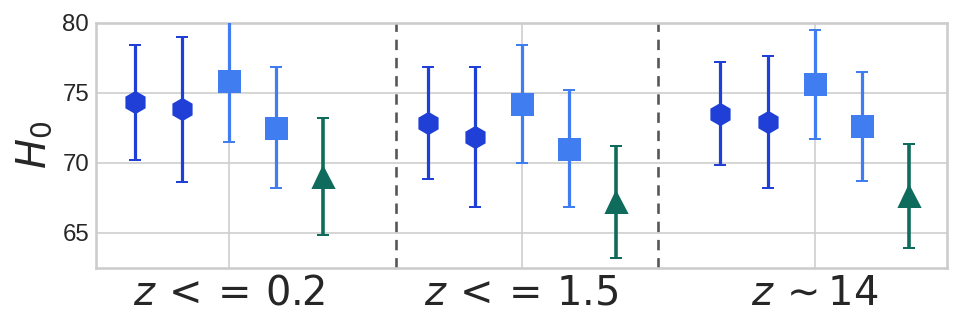

In [25]:

from pprint import pprint

texto = """
        Main_Full_CepcZeR_sigma_w         Full CepcZeR_sigma_w        h 0.755575 0.039035     OK
        Main_Full_CepcZeT_sigma_w         Full CepcZeT_sigma_w        h 0.726103 0.038520     OK
        Main_Full_CepnZeR_sigma_w         Full CepnZeR_sigma_w        h 0.735094 0.037107     OK
        Main_Full_CepnZeT_sigma_w         Full CepnZeT_sigma_w        h 0.728664 0.046883     OK
           Main_Full_TRGB_sigma_w         Full    TRGB_sigma_w        h 0.676265 0.036661     OK
Main_Intermediate_CepcZeR_sigma_w Intermediate CepcZeR_sigma_w        h 0.741596 0.042225     OK
Main_Intermediate_CepcZeT_sigma_w Intermediate CepcZeT_sigma_w        h 0.709986 0.041778     OK
Main_Intermediate_CepnZeR_sigma_w Intermediate CepnZeR_sigma_w        h 0.727587 0.039835     OK
Main_Intermediate_CepnZeT_sigma_w Intermediate CepnZeT_sigma_w        h 0.718043 0.050096     OK
   Main_Intermediate_TRGB_sigma_w Intermediate    TRGB_sigma_w        h 0.671739 0.040353     OK
       Main_Local_CepcZeR_sigma_w        Local CepcZeR_sigma_w        h 0.757520 0.043308     OK
       Main_Local_CepcZeT_sigma_w        Local CepcZeT_sigma_w        h 0.725402 0.043117     OK
       Main_Local_CepnZeR_sigma_w        Local CepnZeR_sigma_w        h 0.743349 0.040504     OK
       Main_Local_CepnZeT_sigma_w        Local CepnZeT_sigma_w        h 0.737846 0.051723     OK
          Main_Local_TRGB_sigma_w        Local    TRGB_sigma_w        h 0.689880 0.041708     OK

"""

grupo = "Main"
rangos = {"Local": 0.2, "Intermediate": 1.5, "Full": 14}
subgrupos = {
    "nometal": ["CepnZeR_sigma_w", "CepnZeT_sigma_w"],
    "metal":   ["CepcZeR_sigma_w", "CepcZeT_sigma_w"],
    "trgb":    ["TRGB_sigma_w"],
}

datos = {}

for linea in texto.splitlines():
    campos = linea.split()  # Admite cualquier cantidad de espacios.
    if len(campos) != 7:
        continue

    carpeta, rango, subgrupo, variable, valor, error, estado = campos

    if (
        carpeta == f"{grupo}_{rango}_{subgrupo}"
        and variable == "h"
        and estado == "OK"
    ):
        datos[(rango, subgrupo)] = (
            round(float(valor) * 100, 1),
            round(float(error) * 100, 1),
        )

# Orden explícito: eR primero y eT después.
# Si falta un resultado requerido, se genera un KeyError.
eta_data = {
    eta: {
        categoria: [datos[(rango, subgrupo)] for subgrupo in nombres]
        for categoria, nombres in subgrupos.items()
    }
    for rango, eta in rangos.items()
}

pprint(eta_data, sort_dicts=False)

"""
Hubble Tension plot - replica del boceto de Holman.
Datos ESTIMADOS a partir de la imagen subida; reemplazar con valores reales
del análisis (L-sigma relation, GEHR/HIIG, etc.) cuando estén disponibles.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# ---------------------------------------------------------------
# 1. DATOS ESTIMADOS (editar aquí con tus valores reales)
# ---------------------------------------------------------------

# --- Bandas de referencia (Planck/LambdaCDM vs SH0ES/Distance Ladder) ---

PLANCK_H0, PLANCK_ERR = 67.4, 0.5
SHOES_H0, SHOES_ERR = 73.04, 1.04

# --- Panel inferior: Evolución con z para "This work" ---
# 3 grupos en z = 0.2, 1.5, 14 ; cada grupo: no-metal, metal, TRGB
z_groups = [0.2, 1.5, 14]
z_offsets = [-0.6, -0.2, 0.2, 0.6]  # no-metal x2, metal x2 dentro de cada grupo (estimado del boceto)


# ---------------------------------------------------------------
# 2. ESTILO
# ---------------------------------------------------------------

COLOR_LCDM = "#2ca02c"       # verde - Historic LCDM
COLOR_DL = "#d62728"         # rojo - Historic Distance Ladder
COLOR_TRGB_HIST = "#17e0c4"  # cian - Historic TRGB
COLOR_NOMETAL = "#1f3fd6"    # azul oscuro - This work no-metalicity
COLOR_METAL = "#3f7df0"      # azul claro - This work metalicity
COLOR_TRGB_NEW = "#0f6b5c"   # verde oscuro - This work TRGB

plt.rcParams.update({
    "font.size": 11,
    "axes.linewidth": 1.3,
    "figure.facecolor": "white",
})


mm_to_inch = 1 / 25.4
# Target size in mm (e.g., 200mm width, 100mm height)
target_width_mm = 317.1
target_height_mm = 110.76
# Invertimos las proporciones de la figura para hacerla alta
fig, ax_bot= plt.subplots(figsize=(target_width_mm * mm_to_inch,target_height_mm * mm_to_inch))
gs = GridSpec(1, 1)


# ---------------------------------------------------------------
# 3. PANEL SUPERIOR
# ---------------------------------------------------------------

# Bandas horizontales sombreadas

#ax_bot.axhspan(PLANCK_H0 - PLANCK_ERR, PLANCK_H0 + PLANCK_ERR,
#            color=COLOR_LCDM, alpha=0.12, zorder=0)
#ax_bot.axhspan(SHOES_H0 - SHOES_ERR, SHOES_H0 + SHOES_ERR,
#            color=COLOR_DL, alpha=0.12, zorder=0)
# ---------------------------------------------------------------
# 5. PANEL INFERIOR: evolución con z
# ---------------------------------------------------------------

xpos = []
xlabels = []
base = 0
group_centers = []

for gi, z in enumerate(z_groups):
    d = eta_data[z]
    n_nometal = len(d["nometal"])
    n_metal = len(d["metal"])
    n_trgb = len(d["trgb"])
    n_total = n_nometal + n_metal + n_trgb
    xs = base + np.arange(n_total) * 0.9
    idx = 0

    for (y, yerr) in d["nometal"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="h", color=COLOR_NOMETAL,
                         ecolor=COLOR_NOMETAL, elinewidth=1.6, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1
    for (y, yerr) in d["metal"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="s", color=COLOR_METAL,
                         ecolor=COLOR_METAL, elinewidth=1.6, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1
    for (y, yerr) in d["trgb"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="^", color=COLOR_TRGB_NEW,
                         ecolor=COLOR_TRGB_NEW, elinewidth=1.8, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1

    group_centers.append(np.mean(xs))
    base = xs[-1] + 2.0  # espacio entre grupos

ax_bot.set_xticks(group_centers)
ax_bot.set_xticklabels([r"$z \,<=\,0.2$",r"$z \,<=\,1.5$",r"$z \, \sim 14$"],fontsize = 20)
ax_bot.set_ylabel(r"$H_0$", fontsize=20)
ax_bot.set_ylim(62.5, 80)

ax_bot.axvline(5, color="#555555", ls=(0, (4, 3)), lw=1.3, zorder=2)
ax_bot.axvline(10, color="#555555", ls=(0, (4, 3)), lw=1.3, zorder=2)

ax_bot.set_position([0.7, 0.7, 0.7, 0.7])

plt.tight_layout() 
plt.savefig(f"CFH_hubble_tension_lowerpanel_{grupo}.png", dpi=300, bbox_inches="tight",transparent = True)

{0.2: {'nometal': [(75.0, 4.0), (73.7, 5.1)],
       'metal': [(77.0, 4.3), (73.5, 4.2)],
       'trgb': [(69.6, 4.1)]},
 1.5: {'nometal': [(73.6, 4.0), (71.5, 5.0)],
       'metal': [(75.3, 4.2), (71.9, 4.2)],
       'trgb': [(67.8, 4.0)]},
 14: {'nometal': [(73.9, 3.7), (72.3, 4.6)],
      'metal': [(76.1, 3.9), (72.9, 3.9)],
      'trgb': [(68.1, 3.6)]}}


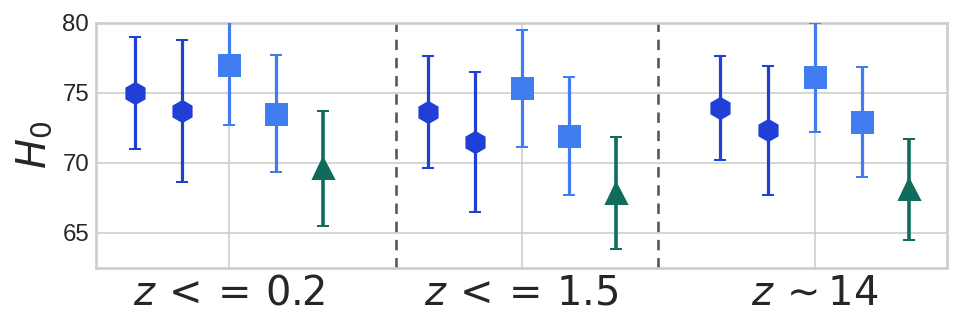

In [26]:

from pprint import pprint

texto = """
        Liter_Full_CepcZeR_sigma_w         Full CepcZeR_sigma_w        h 0.761439 0.038777     OK
        Liter_Full_CepcZeT_sigma_w         Full CepcZeT_sigma_w        h 0.729074 0.038617     OK
        Liter_Full_CepnZeR_sigma_w         Full CepnZeR_sigma_w        h 0.738592 0.036804     OK
        Liter_Full_CepnZeT_sigma_w         Full CepnZeT_sigma_w        h 0.723052 0.045987     OK
           Liter_Full_TRGB_sigma_w         Full    TRGB_sigma_w        h 0.680965 0.036083     OK
Liter_Intermediate_CepcZeR_sigma_w Intermediate CepcZeR_sigma_w        h 0.752950 0.042070     OK
Liter_Intermediate_CepcZeT_sigma_w Intermediate CepcZeT_sigma_w        h 0.718885 0.041927     OK
Liter_Intermediate_CepnZeR_sigma_w Intermediate CepnZeR_sigma_w        h 0.735607 0.039593     OK
Liter_Intermediate_CepnZeT_sigma_w Intermediate CepnZeT_sigma_w        h 0.715468 0.050258     OK
   Liter_Intermediate_TRGB_sigma_w Intermediate    TRGB_sigma_w        h 0.677589 0.039986     OK
       Liter_Local_CepcZeR_sigma_w        Local CepcZeR_sigma_w        h 0.769979 0.042537     OK
       Liter_Local_CepcZeT_sigma_w        Local CepcZeT_sigma_w        h 0.734677 0.042473     OK
       Liter_Local_CepnZeR_sigma_w        Local CepnZeR_sigma_w        h 0.750110 0.040354     OK
       Liter_Local_CepnZeT_sigma_w        Local CepnZeT_sigma_w        h 0.737251 0.050862     OK
          Liter_Local_TRGB_sigma_w        Local    TRGB_sigma_w        h 0.695580 0.040604     OK

"""

grupo = "Liter"
rangos = {"Local": 0.2, "Intermediate": 1.5, "Full": 14}
subgrupos = {
    "nometal": ["CepnZeR_sigma_w", "CepnZeT_sigma_w"],
    "metal":   ["CepcZeR_sigma_w", "CepcZeT_sigma_w"],
    "trgb":    ["TRGB_sigma_w"],
}

datos = {}

for linea in texto.splitlines():
    campos = linea.split()  # Admite cualquier cantidad de espacios.
    if len(campos) != 7:
        continue

    carpeta, rango, subgrupo, variable, valor, error, estado = campos

    if (
        carpeta == f"{grupo}_{rango}_{subgrupo}"
        and variable == "h"
        and estado == "OK"
    ):
        datos[(rango, subgrupo)] = (
            round(float(valor) * 100, 1),
            round(float(error) * 100, 1),
        )

# Orden explícito: eR primero y eT después.
# Si falta un resultado requerido, se genera un KeyError.
eta_data = {
    eta: {
        categoria: [datos[(rango, subgrupo)] for subgrupo in nombres]
        for categoria, nombres in subgrupos.items()
    }
    for rango, eta in rangos.items()
}

pprint(eta_data, sort_dicts=False)

"""
Hubble Tension plot - replica del boceto de Holman.
Datos ESTIMADOS a partir de la imagen subida; reemplazar con valores reales
del análisis (L-sigma relation, GEHR/HIIG, etc.) cuando estén disponibles.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# ---------------------------------------------------------------
# 1. DATOS ESTIMADOS (editar aquí con tus valores reales)
# ---------------------------------------------------------------

# --- Bandas de referencia (Planck/LambdaCDM vs SH0ES/Distance Ladder) ---

PLANCK_H0, PLANCK_ERR = 67.4, 0.5
SHOES_H0, SHOES_ERR = 73.04, 1.04

# --- Panel inferior: Evolución con z para "This work" ---
# 3 grupos en z = 0.2, 1.5, 14 ; cada grupo: no-metal, metal, TRGB
z_groups = [0.2, 1.5, 14]
z_offsets = [-0.6, -0.2, 0.2, 0.6]  # no-metal x2, metal x2 dentro de cada grupo (estimado del boceto)


# ---------------------------------------------------------------
# 2. ESTILO
# ---------------------------------------------------------------

COLOR_LCDM = "#2ca02c"       # verde - Historic LCDM
COLOR_DL = "#d62728"         # rojo - Historic Distance Ladder
COLOR_TRGB_HIST = "#17e0c4"  # cian - Historic TRGB
COLOR_NOMETAL = "#1f3fd6"    # azul oscuro - This work no-metalicity
COLOR_METAL = "#3f7df0"      # azul claro - This work metalicity
COLOR_TRGB_NEW = "#0f6b5c"   # verde oscuro - This work TRGB

plt.rcParams.update({
    "font.size": 11,
    "axes.linewidth": 1.3,
    "figure.facecolor": "white",
})


mm_to_inch = 1 / 25.4
# Target size in mm (e.g., 200mm width, 100mm height)
target_width_mm = 317.1
target_height_mm = 110.76
# Invertimos las proporciones de la figura para hacerla alta
fig, ax_bot= plt.subplots(figsize=(target_width_mm * mm_to_inch,target_height_mm * mm_to_inch))
gs = GridSpec(1, 1)


# ---------------------------------------------------------------
# 3. PANEL SUPERIOR
# ---------------------------------------------------------------

# Bandas horizontales sombreadas

#ax_bot.axhspan(PLANCK_H0 - PLANCK_ERR, PLANCK_H0 + PLANCK_ERR,
#            color=COLOR_LCDM, alpha=0.12, zorder=0)
#ax_bot.axhspan(SHOES_H0 - SHOES_ERR, SHOES_H0 + SHOES_ERR,
#            color=COLOR_DL, alpha=0.12, zorder=0)
# ---------------------------------------------------------------
# 5. PANEL INFERIOR: evolución con z
# ---------------------------------------------------------------

xpos = []
xlabels = []
base = 0
group_centers = []

for gi, z in enumerate(z_groups):
    d = eta_data[z]
    n_nometal = len(d["nometal"])
    n_metal = len(d["metal"])
    n_trgb = len(d["trgb"])
    n_total = n_nometal + n_metal + n_trgb
    xs = base + np.arange(n_total) * 0.9
    idx = 0

    for (y, yerr) in d["nometal"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="h", color=COLOR_NOMETAL,
                         ecolor=COLOR_NOMETAL, elinewidth=1.6, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1
    for (y, yerr) in d["metal"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="s", color=COLOR_METAL,
                         ecolor=COLOR_METAL, elinewidth=1.6, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1
    for (y, yerr) in d["trgb"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="^", color=COLOR_TRGB_NEW,
                         ecolor=COLOR_TRGB_NEW, elinewidth=1.8, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1

    group_centers.append(np.mean(xs))
    base = xs[-1] + 2.0  # espacio entre grupos

ax_bot.set_xticks(group_centers)
ax_bot.set_xticklabels([r"$z \,<=\,0.2$",r"$z \,<=\,1.5$",r"$z \, \sim 14$"],fontsize = 20)
ax_bot.set_ylabel(r"$H_0$", fontsize=20)
ax_bot.set_ylim(62.5, 80)

ax_bot.axvline(5, color="#555555", ls=(0, (4, 3)), lw=1.3, zorder=2)
ax_bot.axvline(10, color="#555555", ls=(0, (4, 3)), lw=1.3, zorder=2)

ax_bot.set_position([0.7, 0.7, 0.7, 0.7])

plt.tight_layout() 
plt.savefig(f"CFH_hubble_tension_lowerpanel_{grupo}.png", dpi=300, bbox_inches="tight",transparent = True)

{0.2: {'nometal': [(70.4, 3.7), (75.3, 5.0)],
       'metal': [(71.8, 4.0), (68.9, 3.9)],
       'trgb': [(67.3, 3.7)]},
 1.5: {'nometal': [(69.1, 3.7), (73.1, 4.9)],
       'metal': [(70.4, 3.9), (67.4, 3.9)],
       'trgb': [(65.9, 3.6)]},
 14: {'nometal': [(69.8, 3.4), (73.9, 4.5)],
      'metal': [(71.4, 3.6), (68.6, 3.5)],
      'trgb': [(66.1, 3.3)]}}


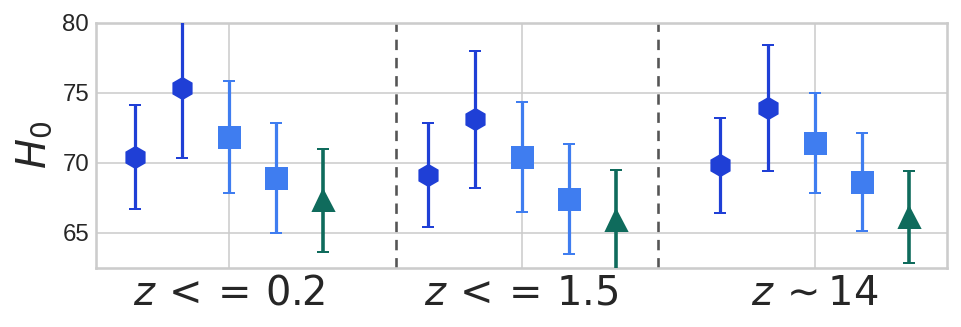

In [27]:

from pprint import pprint

texto = """
        MockA_Full_CepcZeR_sigma_w         Full CepcZeR_sigma_w        h 0.713786 0.035664     OK
        MockA_Full_CepcZeT_sigma_w         Full CepcZeT_sigma_w        h 0.686007 0.035335     OK
        MockA_Full_CepnZeR_sigma_w         Full CepnZeR_sigma_w        h 0.698468 0.034309     OK
        MockA_Full_CepnZeT_sigma_w         Full CepnZeT_sigma_w        h 0.739309 0.045105     OK
           MockA_Full_TRGB_sigma_w         Full    TRGB_sigma_w        h 0.661267 0.033087     OK
MockA_Intermediate_CepcZeR_sigma_w Intermediate CepcZeR_sigma_w        h 0.703530 0.038810     OK
MockA_Intermediate_CepcZeT_sigma_w Intermediate CepcZeT_sigma_w        h 0.674479 0.038606     OK
MockA_Intermediate_CepnZeR_sigma_w Intermediate CepnZeR_sigma_w        h 0.690852 0.036648     OK
MockA_Intermediate_CepnZeT_sigma_w Intermediate CepnZeT_sigma_w        h 0.731353 0.048938     OK
   MockA_Intermediate_TRGB_sigma_w Intermediate    TRGB_sigma_w        h 0.658834 0.036125     OK
       MockA_Local_CepcZeR_sigma_w        Local CepcZeR_sigma_w        h 0.717899 0.040197     OK
       MockA_Local_CepcZeT_sigma_w        Local CepcZeT_sigma_w        h 0.689127 0.039216     OK
       MockA_Local_CepnZeR_sigma_w        Local CepnZeR_sigma_w        h 0.704197 0.037280     OK
       MockA_Local_CepnZeT_sigma_w        Local CepnZeT_sigma_w        h 0.752746 0.050335     OK
          MockA_Local_TRGB_sigma_w        Local    TRGB_sigma_w        h 0.673196 0.037219     OK

"""

grupo = "MockA"
rangos = {"Local": 0.2, "Intermediate": 1.5, "Full": 14}
subgrupos = {
    "nometal": ["CepnZeR_sigma_w", "CepnZeT_sigma_w"],
    "metal":   ["CepcZeR_sigma_w", "CepcZeT_sigma_w"],
    "trgb":    ["TRGB_sigma_w"],
}

datos = {}

for linea in texto.splitlines():
    campos = linea.split()  # Admite cualquier cantidad de espacios.
    if len(campos) != 7:
        continue

    carpeta, rango, subgrupo, variable, valor, error, estado = campos

    if (
        carpeta == f"{grupo}_{rango}_{subgrupo}"
        and variable == "h"
        and estado == "OK"
    ):
        datos[(rango, subgrupo)] = (
            round(float(valor) * 100, 1),
            round(float(error) * 100, 1),
        )

# Orden explícito: eR primero y eT después.
# Si falta un resultado requerido, se genera un KeyError.
eta_data = {
    eta: {
        categoria: [datos[(rango, subgrupo)] for subgrupo in nombres]
        for categoria, nombres in subgrupos.items()
    }
    for rango, eta in rangos.items()
}

pprint(eta_data, sort_dicts=False)

"""
Hubble Tension plot - replica del boceto de Holman.
Datos ESTIMADOS a partir de la imagen subida; reemplazar con valores reales
del análisis (L-sigma relation, GEHR/HIIG, etc.) cuando estén disponibles.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# ---------------------------------------------------------------
# 1. DATOS ESTIMADOS (editar aquí con tus valores reales)
# ---------------------------------------------------------------

# --- Bandas de referencia (Planck/LambdaCDM vs SH0ES/Distance Ladder) ---

PLANCK_H0, PLANCK_ERR = 67.4, 0.5
SHOES_H0, SHOES_ERR = 73.04, 1.04

# --- Panel inferior: Evolución con z para "This work" ---
# 3 grupos en z = 0.2, 1.5, 14 ; cada grupo: no-metal, metal, TRGB
z_groups = [0.2, 1.5, 14]
z_offsets = [-0.6, -0.2, 0.2, 0.6]  # no-metal x2, metal x2 dentro de cada grupo (estimado del boceto)


# ---------------------------------------------------------------
# 2. ESTILO
# ---------------------------------------------------------------

COLOR_LCDM = "#2ca02c"       # verde - Historic LCDM
COLOR_DL = "#d62728"         # rojo - Historic Distance Ladder
COLOR_TRGB_HIST = "#17e0c4"  # cian - Historic TRGB
COLOR_NOMETAL = "#1f3fd6"    # azul oscuro - This work no-metalicity
COLOR_METAL = "#3f7df0"      # azul claro - This work metalicity
COLOR_TRGB_NEW = "#0f6b5c"   # verde oscuro - This work TRGB

plt.rcParams.update({
    "font.size": 11,
    "axes.linewidth": 1.3,
    "figure.facecolor": "white",
})


mm_to_inch = 1 / 25.4
# Target size in mm (e.g., 200mm width, 100mm height)
target_width_mm = 317.1
target_height_mm = 110.76
# Invertimos las proporciones de la figura para hacerla alta
fig, ax_bot= plt.subplots(figsize=(target_width_mm * mm_to_inch,target_height_mm * mm_to_inch))
gs = GridSpec(1, 1)


# ---------------------------------------------------------------
# 3. PANEL SUPERIOR
# ---------------------------------------------------------------

# Bandas horizontales sombreadas

#ax_bot.axhspan(PLANCK_H0 - PLANCK_ERR, PLANCK_H0 + PLANCK_ERR,
#            color=COLOR_LCDM, alpha=0.12, zorder=0)
#ax_bot.axhspan(SHOES_H0 - SHOES_ERR, SHOES_H0 + SHOES_ERR,
#            color=COLOR_DL, alpha=0.12, zorder=0)
# ---------------------------------------------------------------
# 5. PANEL INFERIOR: evolución con z
# ---------------------------------------------------------------

xpos = []
xlabels = []
base = 0
group_centers = []

for gi, z in enumerate(z_groups):
    d = eta_data[z]
    n_nometal = len(d["nometal"])
    n_metal = len(d["metal"])
    n_trgb = len(d["trgb"])
    n_total = n_nometal + n_metal + n_trgb
    xs = base + np.arange(n_total) * 0.9
    idx = 0

    for (y, yerr) in d["nometal"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="h", color=COLOR_NOMETAL,
                         ecolor=COLOR_NOMETAL, elinewidth=1.6, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1
    for (y, yerr) in d["metal"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="s", color=COLOR_METAL,
                         ecolor=COLOR_METAL, elinewidth=1.6, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1
    for (y, yerr) in d["trgb"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="^", color=COLOR_TRGB_NEW,
                         ecolor=COLOR_TRGB_NEW, elinewidth=1.8, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1

    group_centers.append(np.mean(xs))
    base = xs[-1] + 2.0  # espacio entre grupos

ax_bot.set_xticks(group_centers)
ax_bot.set_xticklabels([r"$z \,<=\,0.2$",r"$z \,<=\,1.5$",r"$z \, \sim 14$"],fontsize = 20)
ax_bot.set_ylabel(r"$H_0$", fontsize=20)
ax_bot.set_ylim(62.5, 80)

ax_bot.axvline(5, color="#555555", ls=(0, (4, 3)), lw=1.3, zorder=2)
ax_bot.axvline(10, color="#555555", ls=(0, (4, 3)), lw=1.3, zorder=2)

ax_bot.set_position([0.7, 0.7, 0.7, 0.7])

plt.tight_layout() 
plt.savefig(f"CFH_hubble_tension_lowerpanel_{grupo}.png", dpi=300, bbox_inches="tight",transparent = True)

{0.2: {'nometal': [(74.4, 4.0), (73.7, 5.0)],
       'metal': [(75.8, 4.3), (72.1, 4.2)],
       'trgb': [(68.5, 4.0)]},
 1.5: {'nometal': [(72.9, 3.9), (71.6, 4.9)],
       'metal': [(74.3, 4.2), (70.6, 4.1)],
       'trgb': [(67.0, 3.9)]},
 14: {'nometal': [(73.7, 3.7), (72.7, 4.6)],
      'metal': [(75.5, 3.8), (72.1, 3.8)],
      'trgb': [(67.5, 3.6)]}}


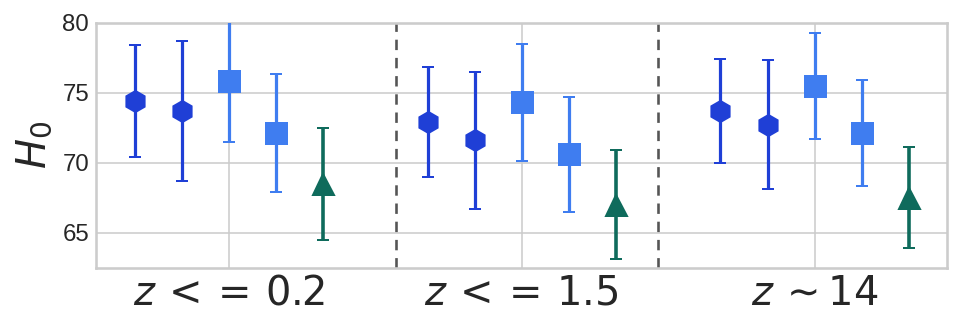

In [28]:

from pprint import pprint

texto = """
        MockB_Full_CepcZeR_sigma_w         Full CepcZeR_sigma_w        h 0.755168 0.038449     OK
        MockB_Full_CepcZeT_sigma_w         Full CepcZeT_sigma_w        h 0.720873 0.038021     OK
        MockB_Full_CepnZeR_sigma_w         Full CepnZeR_sigma_w        h 0.736606 0.036857     OK
        MockB_Full_CepnZeT_sigma_w         Full CepnZeT_sigma_w        h 0.727181 0.045509     OK
           MockB_Full_TRGB_sigma_w         Full    TRGB_sigma_w        h 0.675499 0.035522     OK
MockB_Intermediate_CepcZeR_sigma_w Intermediate CepcZeR_sigma_w        h 0.742697 0.041714     OK
MockB_Intermediate_CepcZeT_sigma_w Intermediate CepcZeT_sigma_w        h 0.705928 0.040983     OK
MockB_Intermediate_CepnZeR_sigma_w Intermediate CepnZeR_sigma_w        h 0.729206 0.039457     OK
MockB_Intermediate_CepnZeT_sigma_w Intermediate CepnZeT_sigma_w        h 0.716109 0.049146     OK
   MockB_Intermediate_TRGB_sigma_w Intermediate    TRGB_sigma_w        h 0.670076 0.038805     OK
       MockB_Local_CepcZeR_sigma_w        Local CepcZeR_sigma_w        h 0.758142 0.042739     OK
       MockB_Local_CepcZeT_sigma_w        Local CepcZeT_sigma_w        h 0.721417 0.042087     OK
       MockB_Local_CepnZeR_sigma_w        Local CepnZeR_sigma_w        h 0.744370 0.040290     OK
       MockB_Local_CepnZeT_sigma_w        Local CepnZeT_sigma_w        h 0.736919 0.050361     OK
          MockB_Local_TRGB_sigma_w        Local    TRGB_sigma_w        h 0.685019 0.039738     OK

"""

grupo = "MockB"
rangos = {"Local": 0.2, "Intermediate": 1.5, "Full": 14}
subgrupos = {
    "nometal": ["CepnZeR_sigma_w", "CepnZeT_sigma_w"],
    "metal":   ["CepcZeR_sigma_w", "CepcZeT_sigma_w"],
    "trgb":    ["TRGB_sigma_w"],
}

datos = {}

for linea in texto.splitlines():
    campos = linea.split()  # Admite cualquier cantidad de espacios.
    if len(campos) != 7:
        continue

    carpeta, rango, subgrupo, variable, valor, error, estado = campos

    if (
        carpeta == f"{grupo}_{rango}_{subgrupo}"
        and variable == "h"
        and estado == "OK"
    ):
        datos[(rango, subgrupo)] = (
            round(float(valor) * 100, 1),
            round(float(error) * 100, 1),
        )

# Orden explícito: eR primero y eT después.
# Si falta un resultado requerido, se genera un KeyError.
eta_data = {
    eta: {
        categoria: [datos[(rango, subgrupo)] for subgrupo in nombres]
        for categoria, nombres in subgrupos.items()
    }
    for rango, eta in rangos.items()
}

pprint(eta_data, sort_dicts=False)

"""
Hubble Tension plot - replica del boceto de Holman.
Datos ESTIMADOS a partir de la imagen subida; reemplazar con valores reales
del análisis (L-sigma relation, GEHR/HIIG, etc.) cuando estén disponibles.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# ---------------------------------------------------------------
# 1. DATOS ESTIMADOS (editar aquí con tus valores reales)
# ---------------------------------------------------------------

# --- Bandas de referencia (Planck/LambdaCDM vs SH0ES/Distance Ladder) ---

PLANCK_H0, PLANCK_ERR = 67.4, 0.5
SHOES_H0, SHOES_ERR = 73.04, 1.04

# --- Panel inferior: Evolución con z para "This work" ---
# 3 grupos en z = 0.2, 1.5, 14 ; cada grupo: no-metal, metal, TRGB
z_groups = [0.2, 1.5, 14]
z_offsets = [-0.6, -0.2, 0.2, 0.6]  # no-metal x2, metal x2 dentro de cada grupo (estimado del boceto)


# ---------------------------------------------------------------
# 2. ESTILO
# ---------------------------------------------------------------

COLOR_LCDM = "#2ca02c"       # verde - Historic LCDM
COLOR_DL = "#d62728"         # rojo - Historic Distance Ladder
COLOR_TRGB_HIST = "#17e0c4"  # cian - Historic TRGB
COLOR_NOMETAL = "#1f3fd6"    # azul oscuro - This work no-metalicity
COLOR_METAL = "#3f7df0"      # azul claro - This work metalicity
COLOR_TRGB_NEW = "#0f6b5c"   # verde oscuro - This work TRGB

plt.rcParams.update({
    "font.size": 11,
    "axes.linewidth": 1.3,
    "figure.facecolor": "white",
})


mm_to_inch = 1 / 25.4
# Target size in mm (e.g., 200mm width, 100mm height)
target_width_mm = 317.1
target_height_mm = 110.76
# Invertimos las proporciones de la figura para hacerla alta
fig, ax_bot= plt.subplots(figsize=(target_width_mm * mm_to_inch,target_height_mm * mm_to_inch))
gs = GridSpec(1, 1)


# ---------------------------------------------------------------
# 3. PANEL SUPERIOR
# ---------------------------------------------------------------

# Bandas horizontales sombreadas

#ax_bot.axhspan(PLANCK_H0 - PLANCK_ERR, PLANCK_H0 + PLANCK_ERR,
#            color=COLOR_LCDM, alpha=0.12, zorder=0)
#ax_bot.axhspan(SHOES_H0 - SHOES_ERR, SHOES_H0 + SHOES_ERR,
#            color=COLOR_DL, alpha=0.12, zorder=0)
# ---------------------------------------------------------------
# 5. PANEL INFERIOR: evolución con z
# ---------------------------------------------------------------

xpos = []
xlabels = []
base = 0
group_centers = []

for gi, z in enumerate(z_groups):
    d = eta_data[z]
    n_nometal = len(d["nometal"])
    n_metal = len(d["metal"])
    n_trgb = len(d["trgb"])
    n_total = n_nometal + n_metal + n_trgb
    xs = base + np.arange(n_total) * 0.9
    idx = 0

    for (y, yerr) in d["nometal"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="h", color=COLOR_NOMETAL,
                         ecolor=COLOR_NOMETAL, elinewidth=1.6, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1
    for (y, yerr) in d["metal"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="s", color=COLOR_METAL,
                         ecolor=COLOR_METAL, elinewidth=1.6, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1
    for (y, yerr) in d["trgb"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="^", color=COLOR_TRGB_NEW,
                         ecolor=COLOR_TRGB_NEW, elinewidth=1.8, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1

    group_centers.append(np.mean(xs))
    base = xs[-1] + 2.0  # espacio entre grupos

ax_bot.set_xticks(group_centers)
ax_bot.set_xticklabels([r"$z \,<=\,0.2$",r"$z \,<=\,1.5$",r"$z \, \sim 14$"],fontsize = 20)
ax_bot.set_ylabel(r"$H_0$", fontsize=20)
ax_bot.set_ylim(62.5, 80)

ax_bot.axvline(5, color="#555555", ls=(0, (4, 3)), lw=1.3, zorder=2)
ax_bot.axvline(10, color="#555555", ls=(0, (4, 3)), lw=1.3, zorder=2)

ax_bot.set_position([0.7, 0.7, 0.7, 0.7])

plt.tight_layout() 
plt.savefig(f"CFH_hubble_tension_lowerpanel_{grupo}.png", dpi=300, bbox_inches="tight",transparent = True)

{0.2: {'nometal': [(73.4, 3.8), (76.1, 4.8)],
       'metal': [(74.2, 4.0), (71.4, 3.9)],
       'trgb': [(69.7, 3.8)]},
 1.5: {'nometal': [(72.1, 3.7), (73.8, 4.7)],
       'metal': [(72.7, 3.9), (70.0, 3.8)],
       'trgb': [(68.2, 3.8)]},
 14: {'nometal': [(72.4, 3.4), (73.7, 4.3)],
      'metal': [(73.4, 3.5), (70.8, 3.5)],
      'trgb': [(68.0, 3.4)]}}


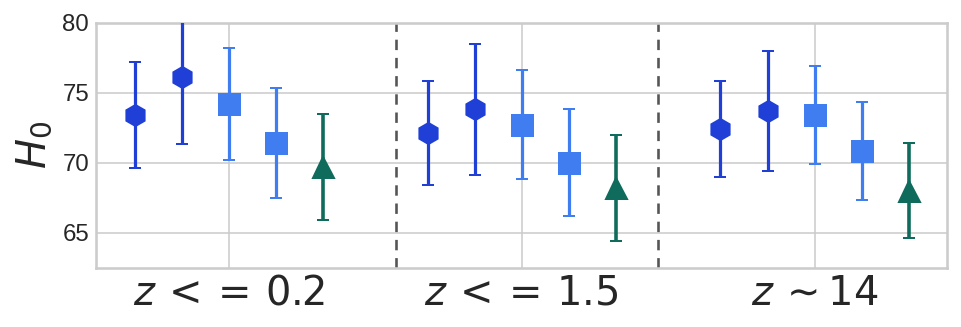

In [29]:

from pprint import pprint

texto = """
        MockC_Full_CepcZeR_sigma_w         Full CepcZeR_sigma_w        h 0.733928 0.035335     OK
        MockC_Full_CepcZeT_sigma_w         Full CepcZeT_sigma_w        h 0.708080 0.034832     OK
        MockC_Full_CepnZeR_sigma_w         Full CepnZeR_sigma_w        h 0.723567 0.033991     OK
        MockC_Full_CepnZeT_sigma_w         Full CepnZeT_sigma_w        h 0.736725 0.042887     OK
           MockC_Full_TRGB_sigma_w         Full    TRGB_sigma_w        h 0.680404 0.034159     OK
MockC_Intermediate_CepcZeR_sigma_w Intermediate CepcZeR_sigma_w        h 0.726832 0.038678     OK
MockC_Intermediate_CepcZeT_sigma_w Intermediate CepcZeT_sigma_w        h 0.699916 0.038183     OK
MockC_Intermediate_CepnZeR_sigma_w Intermediate CepnZeR_sigma_w        h 0.720508 0.037222     OK
MockC_Intermediate_CepnZeT_sigma_w Intermediate CepnZeT_sigma_w        h 0.738175 0.046604     OK
   MockC_Intermediate_TRGB_sigma_w Intermediate    TRGB_sigma_w        h 0.681839 0.037572     OK
       MockC_Local_CepcZeR_sigma_w        Local CepcZeR_sigma_w        h 0.741502 0.039630     OK
       MockC_Local_CepcZeT_sigma_w        Local CepcZeT_sigma_w        h 0.714195 0.038825     OK
       MockC_Local_CepnZeR_sigma_w        Local CepnZeR_sigma_w        h 0.733751 0.037819     OK
       MockC_Local_CepnZeT_sigma_w        Local CepnZeT_sigma_w        h 0.761350 0.047572     OK
          MockC_Local_TRGB_sigma_w        Local    TRGB_sigma_w        h 0.697428 0.038041     OK

"""

grupo = "MockC"
rangos = {"Local": 0.2, "Intermediate": 1.5, "Full": 14}
subgrupos = {
    "nometal": ["CepnZeR_sigma_w", "CepnZeT_sigma_w"],
    "metal":   ["CepcZeR_sigma_w", "CepcZeT_sigma_w"],
    "trgb":    ["TRGB_sigma_w"],
}

datos = {}

for linea in texto.splitlines():
    campos = linea.split()  # Admite cualquier cantidad de espacios.
    if len(campos) != 7:
        continue

    carpeta, rango, subgrupo, variable, valor, error, estado = campos

    if (
        carpeta == f"{grupo}_{rango}_{subgrupo}"
        and variable == "h"
        and estado == "OK"
    ):
        datos[(rango, subgrupo)] = (
            round(float(valor) * 100, 1),
            round(float(error) * 100, 1),
        )

# Orden explícito: eR primero y eT después.
# Si falta un resultado requerido, se genera un KeyError.
eta_data = {
    eta: {
        categoria: [datos[(rango, subgrupo)] for subgrupo in nombres]
        for categoria, nombres in subgrupos.items()
    }
    for rango, eta in rangos.items()
}

pprint(eta_data, sort_dicts=False)

"""
Hubble Tension plot - replica del boceto de Holman.
Datos ESTIMADOS a partir de la imagen subida; reemplazar con valores reales
del análisis (L-sigma relation, GEHR/HIIG, etc.) cuando estén disponibles.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# ---------------------------------------------------------------
# 1. DATOS ESTIMADOS (editar aquí con tus valores reales)
# ---------------------------------------------------------------

# --- Bandas de referencia (Planck/LambdaCDM vs SH0ES/Distance Ladder) ---

PLANCK_H0, PLANCK_ERR = 67.4, 0.5
SHOES_H0, SHOES_ERR = 73.04, 1.04

# --- Panel inferior: Evolución con z para "This work" ---
# 3 grupos en z = 0.2, 1.5, 14 ; cada grupo: no-metal, metal, TRGB
z_groups = [0.2, 1.5, 14]
z_offsets = [-0.6, -0.2, 0.2, 0.6]  # no-metal x2, metal x2 dentro de cada grupo (estimado del boceto)


# ---------------------------------------------------------------
# 2. ESTILO
# ---------------------------------------------------------------

COLOR_LCDM = "#2ca02c"       # verde - Historic LCDM
COLOR_DL = "#d62728"         # rojo - Historic Distance Ladder
COLOR_TRGB_HIST = "#17e0c4"  # cian - Historic TRGB
COLOR_NOMETAL = "#1f3fd6"    # azul oscuro - This work no-metalicity
COLOR_METAL = "#3f7df0"      # azul claro - This work metalicity
COLOR_TRGB_NEW = "#0f6b5c"   # verde oscuro - This work TRGB

plt.rcParams.update({
    "font.size": 11,
    "axes.linewidth": 1.3,
    "figure.facecolor": "white",
})


mm_to_inch = 1 / 25.4
# Target size in mm (e.g., 200mm width, 100mm height)
target_width_mm = 317.1
target_height_mm = 110.76
# Invertimos las proporciones de la figura para hacerla alta
fig, ax_bot= plt.subplots(figsize=(target_width_mm * mm_to_inch,target_height_mm * mm_to_inch))
gs = GridSpec(1, 1)


# ---------------------------------------------------------------
# 3. PANEL SUPERIOR
# ---------------------------------------------------------------

# Bandas horizontales sombreadas

#ax_bot.axhspan(PLANCK_H0 - PLANCK_ERR, PLANCK_H0 + PLANCK_ERR,
#            color=COLOR_LCDM, alpha=0.12, zorder=0)
#ax_bot.axhspan(SHOES_H0 - SHOES_ERR, SHOES_H0 + SHOES_ERR,
#            color=COLOR_DL, alpha=0.12, zorder=0)
# ---------------------------------------------------------------
# 5. PANEL INFERIOR: evolución con z
# ---------------------------------------------------------------

xpos = []
xlabels = []
base = 0
group_centers = []

for gi, z in enumerate(z_groups):
    d = eta_data[z]
    n_nometal = len(d["nometal"])
    n_metal = len(d["metal"])
    n_trgb = len(d["trgb"])
    n_total = n_nometal + n_metal + n_trgb
    xs = base + np.arange(n_total) * 0.9
    idx = 0

    for (y, yerr) in d["nometal"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="h", color=COLOR_NOMETAL,
                         ecolor=COLOR_NOMETAL, elinewidth=1.6, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1
    for (y, yerr) in d["metal"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="s", color=COLOR_METAL,
                         ecolor=COLOR_METAL, elinewidth=1.6, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1
    for (y, yerr) in d["trgb"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="^", color=COLOR_TRGB_NEW,
                         ecolor=COLOR_TRGB_NEW, elinewidth=1.8, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1

    group_centers.append(np.mean(xs))
    base = xs[-1] + 2.0  # espacio entre grupos

ax_bot.set_xticks(group_centers)
ax_bot.set_xticklabels([r"$z \,<=\,0.2$",r"$z \,<=\,1.5$",r"$z \, \sim 14$"],fontsize = 20)
ax_bot.set_ylabel(r"$H_0$", fontsize=20)
ax_bot.set_ylim(62.5, 80)

ax_bot.axvline(5, color="#555555", ls=(0, (4, 3)), lw=1.3, zorder=2)
ax_bot.axvline(10, color="#555555", ls=(0, (4, 3)), lw=1.3, zorder=2)

ax_bot.set_position([0.7, 0.7, 0.7, 0.7])

plt.tight_layout() 
plt.savefig(f"CFH_hubble_tension_lowerpanel_{grupo}.png", dpi=300, bbox_inches="tight",transparent = True)

{0.2: {'nometal': [(74.5, 3.6), (73.7, 4.8)],
       'metal': [(73.9, 3.7), (71.3, 3.6)],
       'trgb': [(71.5, 3.3)]},
 1.5: {'nometal': [(73.4, 3.5), (71.6, 4.7)],
       'metal': [(72.8, 3.7), (70.2, 3.6)],
       'trgb': [(70.6, 3.2)]},
 14: {'nometal': [(73.6, 3.3), (72.7, 4.3)],
      'metal': [(73.5, 3.3), (70.9, 3.4)],
      'trgb': [(70.5, 3.1)]}}


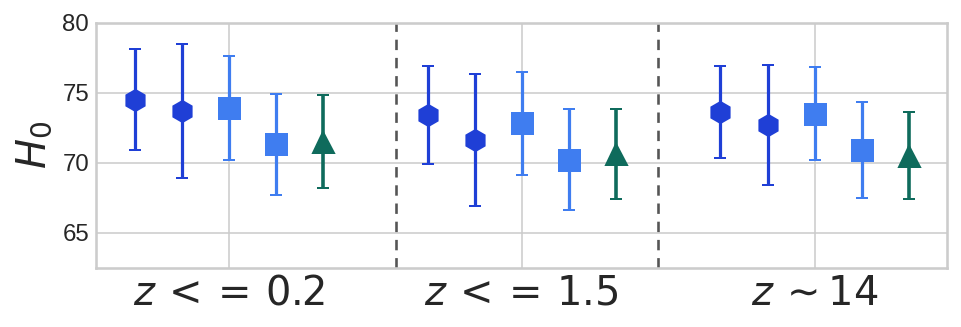

In [30]:

from pprint import pprint

texto = """
        MockD_Full_CepcZeR_sigma_w         Full CepcZeR_sigma_w        h 0.735204 0.033415     OK
        MockD_Full_CepcZeT_sigma_w         Full CepcZeT_sigma_w        h 0.708659 0.033804     OK
        MockD_Full_CepnZeR_sigma_w         Full CepnZeR_sigma_w        h 0.735661 0.033069     OK
        MockD_Full_CepnZeT_sigma_w         Full CepnZeT_sigma_w        h 0.726564 0.043244     OK
           MockD_Full_TRGB_sigma_w         Full    TRGB_sigma_w        h 0.705149 0.030973     OK
MockD_Intermediate_CepcZeR_sigma_w Intermediate CepcZeR_sigma_w        h 0.727804 0.036614     OK
MockD_Intermediate_CepcZeT_sigma_w Intermediate CepcZeT_sigma_w        h 0.701902 0.035883     OK
MockD_Intermediate_CepnZeR_sigma_w Intermediate CepnZeR_sigma_w        h 0.734258 0.035254     OK
MockD_Intermediate_CepnZeT_sigma_w Intermediate CepnZeT_sigma_w        h 0.715699 0.046918     OK
   MockD_Intermediate_TRGB_sigma_w Intermediate    TRGB_sigma_w        h 0.706176 0.032449     OK
       MockD_Local_CepcZeR_sigma_w        Local CepcZeR_sigma_w        h 0.738929 0.036670     OK
       MockD_Local_CepcZeT_sigma_w        Local CepcZeT_sigma_w        h 0.712736 0.036405     OK
       MockD_Local_CepnZeR_sigma_w        Local CepnZeR_sigma_w        h 0.744867 0.035744     OK
       MockD_Local_CepnZeT_sigma_w        Local CepnZeT_sigma_w        h 0.737424 0.048451     OK
          MockD_Local_TRGB_sigma_w        Local    TRGB_sigma_w        h 0.714590 0.032788     OK

"""

grupo = "MockD"
rangos = {"Local": 0.2, "Intermediate": 1.5, "Full": 14}
subgrupos = {
    "nometal": ["CepnZeR_sigma_w", "CepnZeT_sigma_w"],
    "metal":   ["CepcZeR_sigma_w", "CepcZeT_sigma_w"],
    "trgb":    ["TRGB_sigma_w"],
}

datos = {}

for linea in texto.splitlines():
    campos = linea.split()  # Admite cualquier cantidad de espacios.
    if len(campos) != 7:
        continue

    carpeta, rango, subgrupo, variable, valor, error, estado = campos

    if (
        carpeta == f"{grupo}_{rango}_{subgrupo}"
        and variable == "h"
        and estado == "OK"
    ):
        datos[(rango, subgrupo)] = (
            round(float(valor) * 100, 1),
            round(float(error) * 100, 1),
        )

# Orden explícito: eR primero y eT después.
# Si falta un resultado requerido, se genera un KeyError.
eta_data = {
    eta: {
        categoria: [datos[(rango, subgrupo)] for subgrupo in nombres]
        for categoria, nombres in subgrupos.items()
    }
    for rango, eta in rangos.items()
}

pprint(eta_data, sort_dicts=False)

"""
Hubble Tension plot - replica del boceto de Holman.
Datos ESTIMADOS a partir de la imagen subida; reemplazar con valores reales
del análisis (L-sigma relation, GEHR/HIIG, etc.) cuando estén disponibles.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# ---------------------------------------------------------------
# 1. DATOS ESTIMADOS (editar aquí con tus valores reales)
# ---------------------------------------------------------------

# --- Bandas de referencia (Planck/LambdaCDM vs SH0ES/Distance Ladder) ---

PLANCK_H0, PLANCK_ERR = 67.4, 0.5
SHOES_H0, SHOES_ERR = 73.04, 1.04

# --- Panel inferior: Evolución con z para "This work" ---
# 3 grupos en z = 0.2, 1.5, 14 ; cada grupo: no-metal, metal, TRGB
z_groups = [0.2, 1.5, 14]
z_offsets = [-0.6, -0.2, 0.2, 0.6]  # no-metal x2, metal x2 dentro de cada grupo (estimado del boceto)


# ---------------------------------------------------------------
# 2. ESTILO
# ---------------------------------------------------------------

COLOR_LCDM = "#2ca02c"       # verde - Historic LCDM
COLOR_DL = "#d62728"         # rojo - Historic Distance Ladder
COLOR_TRGB_HIST = "#17e0c4"  # cian - Historic TRGB
COLOR_NOMETAL = "#1f3fd6"    # azul oscuro - This work no-metalicity
COLOR_METAL = "#3f7df0"      # azul claro - This work metalicity
COLOR_TRGB_NEW = "#0f6b5c"   # verde oscuro - This work TRGB

plt.rcParams.update({
    "font.size": 11,
    "axes.linewidth": 1.3,
    "figure.facecolor": "white",
})


mm_to_inch = 1 / 25.4
# Target size in mm (e.g., 200mm width, 100mm height)
target_width_mm = 317.1
target_height_mm = 110.76
# Invertimos las proporciones de la figura para hacerla alta
fig, ax_bot= plt.subplots(figsize=(target_width_mm * mm_to_inch,target_height_mm * mm_to_inch))
gs = GridSpec(1, 1)


# ---------------------------------------------------------------
# 3. PANEL SUPERIOR
# ---------------------------------------------------------------

# Bandas horizontales sombreadas

#ax_bot.axhspan(PLANCK_H0 - PLANCK_ERR, PLANCK_H0 + PLANCK_ERR,
#            color=COLOR_LCDM, alpha=0.12, zorder=0)
#ax_bot.axhspan(SHOES_H0 - SHOES_ERR, SHOES_H0 + SHOES_ERR,
#            color=COLOR_DL, alpha=0.12, zorder=0)
# ---------------------------------------------------------------
# 5. PANEL INFERIOR: evolución con z
# ---------------------------------------------------------------

xpos = []
xlabels = []
base = 0
group_centers = []

for gi, z in enumerate(z_groups):
    d = eta_data[z]
    n_nometal = len(d["nometal"])
    n_metal = len(d["metal"])
    n_trgb = len(d["trgb"])
    n_total = n_nometal + n_metal + n_trgb
    xs = base + np.arange(n_total) * 0.9
    idx = 0

    for (y, yerr) in d["nometal"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="h", color=COLOR_NOMETAL,
                         ecolor=COLOR_NOMETAL, elinewidth=1.6, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1
    for (y, yerr) in d["metal"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="s", color=COLOR_METAL,
                         ecolor=COLOR_METAL, elinewidth=1.6, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1
    for (y, yerr) in d["trgb"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="^", color=COLOR_TRGB_NEW,
                         ecolor=COLOR_TRGB_NEW, elinewidth=1.8, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1

    group_centers.append(np.mean(xs))
    base = xs[-1] + 2.0  # espacio entre grupos

ax_bot.set_xticks(group_centers)
ax_bot.set_xticklabels([r"$z \,<=\,0.2$",r"$z \,<=\,1.5$",r"$z \, \sim 14$"],fontsize = 20)
ax_bot.set_ylabel(r"$H_0$", fontsize=20)
ax_bot.set_ylim(62.5, 80)

ax_bot.axvline(5, color="#555555", ls=(0, (4, 3)), lw=1.3, zorder=2)
ax_bot.axvline(10, color="#555555", ls=(0, (4, 3)), lw=1.3, zorder=2)

ax_bot.set_position([0.7, 0.7, 0.7, 0.7])

plt.tight_layout() 
plt.savefig(f"CFH_hubble_tension_lowerpanel_{grupo}.png", dpi=300, bbox_inches="tight",transparent = True)

{0.2: {'nometal': [(75.1, 3.6), (74.1, 4.8)],
       'metal': [(74.8, 3.7), (72.0, 3.6)],
       'trgb': [(71.8, 3.3)]},
 1.5: {'nometal': [(74.0, 3.5), (72.0, 4.7)],
       'metal': [(73.8, 3.6), (70.9, 3.5)],
       'trgb': [(71.0, 3.3)]},
 14: {'nometal': [(74.0, 3.3), (72.5, 4.3)],
      'metal': [(74.1, 3.4), (71.3, 3.3)],
      'trgb': [(70.8, 3.1)]}}


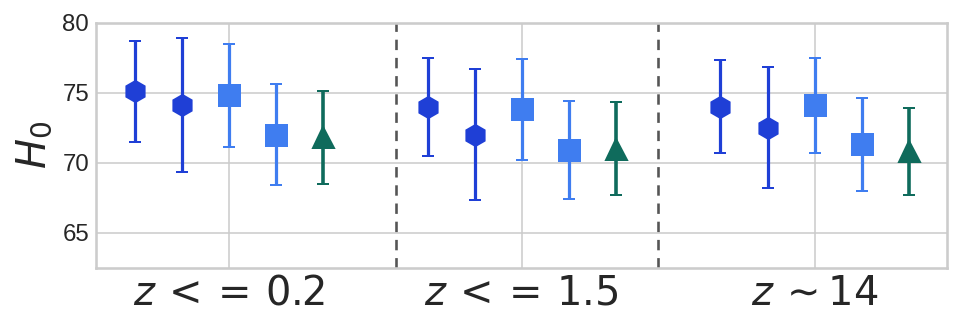

In [31]:

from pprint import pprint

texto = """
        MockE_Full_CepcZeR_sigma_w         Full CepcZeR_sigma_w        h 0.741055 0.033787     OK
        MockE_Full_CepcZeT_sigma_w         Full CepcZeT_sigma_w        h 0.713154 0.033260     OK
        MockE_Full_CepnZeR_sigma_w         Full CepnZeR_sigma_w        h 0.739940 0.032812     OK
        MockE_Full_CepnZeT_sigma_w         Full CepnZeT_sigma_w        h 0.725248 0.042658     OK
           MockE_Full_TRGB_sigma_w         Full    TRGB_sigma_w        h 0.707743 0.030597     OK
MockE_Intermediate_CepcZeR_sigma_w Intermediate CepcZeR_sigma_w        h 0.737975 0.035780     OK
MockE_Intermediate_CepcZeT_sigma_w Intermediate CepcZeT_sigma_w        h 0.709443 0.035427     OK
MockE_Intermediate_CepnZeR_sigma_w Intermediate CepnZeR_sigma_w        h 0.740204 0.035176     OK
MockE_Intermediate_CepnZeT_sigma_w Intermediate CepnZeT_sigma_w        h 0.719832 0.046921     OK
   MockE_Intermediate_TRGB_sigma_w Intermediate    TRGB_sigma_w        h 0.710307 0.032694     OK
       MockE_Local_CepcZeR_sigma_w        Local CepcZeR_sigma_w        h 0.748190 0.036828     OK
       MockE_Local_CepcZeT_sigma_w        Local CepcZeT_sigma_w        h 0.720249 0.036292     OK
       MockE_Local_CepnZeR_sigma_w        Local CepnZeR_sigma_w        h 0.750837 0.035729     OK
       MockE_Local_CepnZeT_sigma_w        Local CepnZeT_sigma_w        h 0.740510 0.047971     OK
          MockE_Local_TRGB_sigma_w        Local    TRGB_sigma_w        h 0.717924 0.032609     OK

"""

grupo = "MockE"
rangos = {"Local": 0.2, "Intermediate": 1.5, "Full": 14}
subgrupos = {
    "nometal": ["CepnZeR_sigma_w", "CepnZeT_sigma_w"],
    "metal":   ["CepcZeR_sigma_w", "CepcZeT_sigma_w"],
    "trgb":    ["TRGB_sigma_w"],
}

datos = {}

for linea in texto.splitlines():
    campos = linea.split()  # Admite cualquier cantidad de espacios.
    if len(campos) != 7:
        continue

    carpeta, rango, subgrupo, variable, valor, error, estado = campos

    if (
        carpeta == f"{grupo}_{rango}_{subgrupo}"
        and variable == "h"
        and estado == "OK"
    ):
        datos[(rango, subgrupo)] = (
            round(float(valor) * 100, 1),
            round(float(error) * 100, 1),
        )

# Orden explícito: eR primero y eT después.
# Si falta un resultado requerido, se genera un KeyError.
eta_data = {
    eta: {
        categoria: [datos[(rango, subgrupo)] for subgrupo in nombres]
        for categoria, nombres in subgrupos.items()
    }
    for rango, eta in rangos.items()
}

pprint(eta_data, sort_dicts=False)

"""
Hubble Tension plot - replica del boceto de Holman.
Datos ESTIMADOS a partir de la imagen subida; reemplazar con valores reales
del análisis (L-sigma relation, GEHR/HIIG, etc.) cuando estén disponibles.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# ---------------------------------------------------------------
# 1. DATOS ESTIMADOS (editar aquí con tus valores reales)
# ---------------------------------------------------------------

# --- Bandas de referencia (Planck/LambdaCDM vs SH0ES/Distance Ladder) ---

PLANCK_H0, PLANCK_ERR = 67.4, 0.5
SHOES_H0, SHOES_ERR = 73.04, 1.04

# --- Panel inferior: Evolución con z para "This work" ---
# 3 grupos en z = 0.2, 1.5, 14 ; cada grupo: no-metal, metal, TRGB
z_groups = [0.2, 1.5, 14]
z_offsets = [-0.6, -0.2, 0.2, 0.6]  # no-metal x2, metal x2 dentro de cada grupo (estimado del boceto)


# ---------------------------------------------------------------
# 2. ESTILO
# ---------------------------------------------------------------

COLOR_LCDM = "#2ca02c"       # verde - Historic LCDM
COLOR_DL = "#d62728"         # rojo - Historic Distance Ladder
COLOR_TRGB_HIST = "#17e0c4"  # cian - Historic TRGB
COLOR_NOMETAL = "#1f3fd6"    # azul oscuro - This work no-metalicity
COLOR_METAL = "#3f7df0"      # azul claro - This work metalicity
COLOR_TRGB_NEW = "#0f6b5c"   # verde oscuro - This work TRGB

plt.rcParams.update({
    "font.size": 11,
    "axes.linewidth": 1.3,
    "figure.facecolor": "white",
})


mm_to_inch = 1 / 25.4
# Target size in mm (e.g., 200mm width, 100mm height)
target_width_mm = 317.1
target_height_mm = 110.76
# Invertimos las proporciones de la figura para hacerla alta
fig, ax_bot= plt.subplots(figsize=(target_width_mm * mm_to_inch,target_height_mm * mm_to_inch))
gs = GridSpec(1, 1)


# ---------------------------------------------------------------
# 3. PANEL SUPERIOR
# ---------------------------------------------------------------

# Bandas horizontales sombreadas

#ax_bot.axhspan(PLANCK_H0 - PLANCK_ERR, PLANCK_H0 + PLANCK_ERR,
#            color=COLOR_LCDM, alpha=0.12, zorder=0)
#ax_bot.axhspan(SHOES_H0 - SHOES_ERR, SHOES_H0 + SHOES_ERR,
#            color=COLOR_DL, alpha=0.12, zorder=0)
# ---------------------------------------------------------------
# 5. PANEL INFERIOR: evolución con z
# ---------------------------------------------------------------

xpos = []
xlabels = []
base = 0
group_centers = []

for gi, z in enumerate(z_groups):
    d = eta_data[z]
    n_nometal = len(d["nometal"])
    n_metal = len(d["metal"])
    n_trgb = len(d["trgb"])
    n_total = n_nometal + n_metal + n_trgb
    xs = base + np.arange(n_total) * 0.9
    idx = 0

    for (y, yerr) in d["nometal"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="h", color=COLOR_NOMETAL,
                         ecolor=COLOR_NOMETAL, elinewidth=1.6, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1
    for (y, yerr) in d["metal"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="s", color=COLOR_METAL,
                         ecolor=COLOR_METAL, elinewidth=1.6, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1
    for (y, yerr) in d["trgb"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="^", color=COLOR_TRGB_NEW,
                         ecolor=COLOR_TRGB_NEW, elinewidth=1.8, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1

    group_centers.append(np.mean(xs))
    base = xs[-1] + 2.0  # espacio entre grupos

ax_bot.set_xticks(group_centers)
ax_bot.set_xticklabels([r"$z \,<=\,0.2$",r"$z \,<=\,1.5$",r"$z \, \sim 14$"],fontsize = 20)
ax_bot.set_ylabel(r"$H_0$", fontsize=20)
ax_bot.set_ylim(62.5, 80)

ax_bot.axvline(5, color="#555555", ls=(0, (4, 3)), lw=1.3, zorder=2)
ax_bot.axvline(10, color="#555555", ls=(0, (4, 3)), lw=1.3, zorder=2)

ax_bot.set_position([0.7, 0.7, 0.7, 0.7])

plt.tight_layout() 
plt.savefig(f"CFH_hubble_tension_lowerpanel_{grupo}.png", dpi=300, bbox_inches="tight",transparent = True)